In [1]:
# Install scanpy and ensure numpy compatibility, then restart
%%capture
!uv pip install numpy pandas matplotlib scanp

In [2]:
# libraries
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import os
import subprocess

warnings.simplefilter(action='ignore', category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

ModuleNotFoundError: No module named 'scanpy'

In [3]:
# 1. Install required single-cell libraries
!pip install -q scanpy harmonypy bbknn scanorama

# 2. Libraries
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import os
import subprocess

warnings.simplefilter(action='ignore', category=Warning)

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.verbosity = 3

sc.settings.set_figure_params(dpi=80)
%matplotlib inline

print("All libraries imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 15.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.8/188.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curren

In [4]:
# Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Set the working directory (adjust the path as needed)
working_dir = "/content/drive/MyDrive/drosophila_scRNAseq_project"
os.chdir(working_dir)

In [7]:
# download pre-computed data if missing or long compute
fetch_data = True

# url for source and intermediate data
path_data = "https://nextcloud.dc.scilifelab.se/public.php/webdav"
curl_upass = "zbC5fr2LbEZ9rSE:scRNAseq2025"

path_results = "data/covid/results"
if not os.path.exists(path_results):
    os.makedirs(path_results, exist_ok=True)

path_file = "data/covid/results/scanpy_covid_qc_dr_int.h5ad"
if fetch_data and not os.path.exists(path_file):
    file_url = os.path.join(path_data, "covid/results_scanpy/scanpy_covid_qc_dr_int.h5ad")
    subprocess.call(["curl", "-u", curl_upass, "-o", path_file, file_url ])

adata = sc.read_h5ad(path_file)
adata

AnnData object with n_obs × n_vars = 7332 × 3984
    obs: 'type', 'sample', 'batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'percent_mt2', 'n_counts', 'n_genes', 'percent_chrY', 'XIST-counts', 'S_score', 'G2M_score', 'phase', 'doublet_scores', 'predicted_doublets', 'doublet_info', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'phase_colors', 'sample_colors', 'tsne', 'umap'
    obsm: 'Scanorama', 'X_pca', 'X_pca_combat', 'X_pca_harmony', 'X_tsne', 'X_tsne_bbknn', 'X_tsne_combat', 'X_tsne_harmony', 'X_tsne_scanorama', 'X_tsne_uncorr', 'X_umap', 'X_umap

In [8]:
adata.obs

,type,sample,batch,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,...,n_genes,percent_chrY,XIST-counts,S_score,G2M_score,phase,doublet_scores,predicted_doublets,doublet_info,leiden
TAGAGTCGTCCTCCAT-1-0,Covid,covid_1,0,779,1613.0,186.0,11.531308,96.0,5.951643,0.0,...,779,0.000000,0.0,-0.046984,-0.102641,G1,0.069767,False,False,0
CCCTGATAGCGAACTG-1-0,Covid,covid_1,0,2036,9482.0,761.0,8.025733,4157.0,43.840962,3.0,...,2036,0.106838,0.0,-0.027485,-0.068665,G1,0.054795,False,False,4
ATTTACCCAAGCCTGC-1-0,Covid,covid_1,0,3290,12466.0,686.0,5.502968,2281.0,18.297770,1.0,...,3290,0.078370,0.0,-0.094133,-0.106045,G1,0.089286,False,False,0
GTTGTCCTCTAGAACC-1-0,Covid,covid_1,0,1606,5541.0,707.0,12.759430,1664.0,30.030680,3.0,...,1606,0.158443,0.0,-0.019133,-0.032468,G1,0.089286,False,False,3
AATAGAGGTGTGAGCA-1-0,Covid,covid_1,0,1285,4736.0,607.0,12.816723,1689.0,35.663007,5.0,...,1285,0.150263,0.0,-0.015961,-0.094780,G1,0.027875,False,False,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTCTTGAGTATCAGGG-19-7,Ctrl,ctrl_19,7,5252,32271.0,2380.0,7.375043,6125.0,18.979889,0.0,...,5252,0.061323,0.0,-0.057091,-0.076524,G1,0.113846,False,False,0
GTAGCTAGTAATGCTC-19-7,Ctrl,ctrl_19,7,1479,4083.0,421.0,10.311046,721.0,17.658584,54.0,...,1479,0.030148,0.0,0.016474,-0.087121,S,0.067568,False,False,1
GCCAACGGTAAGTTAG-19-7,Ctrl,ctrl_19,7,1861,5137.0,472.0,9.188242,953.0,18.551684,5.0,...,1861,0.115128,0.0,-0.011435,-0.105694,G1,0.113846,False,False,1
TCGGGACAGTCGTCTA-19-7,Ctrl,ctrl_19,7,2609,9398.0,534.0,5.682060,2680.0,28.516706,0.0,...,2609,0.171927,0.0,0.114646,-0.074892,S,0.097493,False,False,3


In [10]:
import os
import scanpy as sc

# Set path to your saved integrated Drosophila dataset on Google Drive
path_file = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad"

# Fallback: check raw/filtered location if integrated file hasn't been saved yet
if not os.path.exists(path_file):
    path_file = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad"

print(f"Loading dataset from: {path_file}")
adata = sc.read_h5ad(path_file)

# Display loaded dataset details
print("\nDataset successfully loaded!")
print(adata)

Loading dataset from: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad


TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'

In [11]:
# 1. Update anndata to the latest version compatible with modern Pandas
!pip install -q --upgrade anndata scanpy pandas

import os
import scanpy as sc

# 2. Set path to your saved integrated Drosophila dataset on Google Drive
path_file = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad"

# Fallback: check raw/filtered location if integrated file isn't found
if not os.path.exists(path_file):
    path_file = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad"

print(f"Loading dataset from: {path_file}")
adata = sc.read_h5ad(path_file)

# Display loaded dataset details
print("\nDataset successfully loaded!")
print(adata)

Loading dataset from: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad


TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'

In [12]:
!pip install -q "pandas<2.2.0" "anndata>=0.10.0" scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 36.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [15]:
import os
import scanpy as sc

path_file = "/content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated "

if not os.path.exists(path_file):
    path_file = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad"

print(f"Loading dataset from: {path_file}")
adata = sc.read_h5ad(path_file)

print("\nDataset successfully loaded!")
print(adata)

Loading dataset from: /content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated 


IsADirectoryError: [Errno 21] Unable to synchronously open file (file read failed: time = Thu Sep  3 08:30:45 2026
, filename = '/content/drive/MyDrive/drosophila_scRNAseq_project/data /integrated ', file descriptor = 42, errno = 21, error message = 'Is a directory', buf = 0x7fff1ee584a8, total read size = 8, bytes this sub-read = 8, offset = 0)

In [16]:
import os
import scanpy as sc
from pathlib import Path

# Correct path with exact .h5ad filename and trimmed spaces
integrated_dir = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated")

# Primary integrated file
path_file = integrated_dir / "drosophila_integrated_complete.h5ad"

# Alternative filename check
if not path_file.exists():
    path_file = integrated_dir / "drosophila_scanorama_integrated.h5ad"

print(f"Loading dataset from: {path_file}")

# Load object
adata = sc.read_h5ad(path_file)

print("\nDataset successfully loaded!")
print(adata)

Loading dataset from: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad


TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'

In [17]:
import os
import scanpy as sc
from pathlib import Path

# Set path to integrated file
path_file = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad")

# Fallback check
if not path_file.exists():
    path_file = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_integrated_complete.h5ad")

print(f"Loading dataset from: {path_file}")
adata = sc.read_h5ad(path_file)

print("\n--- Dataset Successfully Loaded! ---")
print(adata)

Loading dataset from: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad


TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'

In [18]:
import pandas as pd
import scanpy as sc
from pathlib import Path

# --- IN-MEMORY COMPATIBILITY PATCH ---
_original_string_dtype_init = pd.StringDtype.__init__

def _patched_string_dtype_init(self, *args, **kwargs):
    kwargs.pop("na_value", None)  # Strip out na_value before passing to pandas
    _original_string_dtype_init(self, *args, **kwargs)

pd.StringDtype.__init__ = _patched_string_dtype_init
# --------------------------------------

path_file = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad")

if not path_file.exists():
    path_file = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_integrated_complete.h5ad")

print(f"Loading dataset with compatibility patch from: {path_file}")
adata = sc.read_h5ad(path_file)

# Restore original behavior
pd.StringDtype.__init__ = _original_string_dtype_init

print("\n--- Dataset Successfully Loaded! ---")
print(adata)

Loading dataset with compatibility patch from: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad

--- Dataset Successfully Loaded! ---
AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_scanorama', 'X_tsne', 'X_tsne_combat', 'X_tsne_scanorama', 'X_umap', 'X_umap_combat', 'X_umap_scanorama'
    varm: 'PCs'
    obsp: 'connectivities', 'd

In [19]:
import os
import pandas as pd
import scanpy as sc
from pathlib import Path

# --- IN-MEMORY COMPATIBILITY PATCH (Fixes pd.StringDtype error) ---
_original_string_dtype_init = pd.StringDtype.__init__

def _patched_string_dtype_init(self, *args, **kwargs):
    kwargs.pop("na_value", None)
    _original_string_dtype_init(self, *args, **kwargs)

pd.StringDtype.__init__ = _patched_string_dtype_init
# -----------------------------------------------------------------

# Path setup for your Drosophila dataset on Google Drive
path_dir = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated")
path_file = path_dir / "drosophila_scanorama_integrated.h5ad"

# Fallbacks if file isn't found under that exact name
if not path_file.exists():
    path_file = path_dir / "drosophila_integrated_complete.h5ad"
if not path_file.exists():
    path_file = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad")

print(f"Loading Drosophila dataset from: {path_file}")

# Load AnnData object
adata = sc.read_h5ad(path_file)

# Restore standard pandas StringDtype initialization
pd.StringDtype.__init__ = _original_string_dtype_init

print("\n--- Drosophila AnnData Successfully Loaded! ---")
print(adata)

Loading Drosophila dataset from: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad

--- Drosophila AnnData Successfully Loaded! ---
AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_scanorama', 'X_tsne', 'X_tsne_combat', 'X_tsne_scanorama', 'X_umap', 'X_umap_combat', 'X_umap_scanorama'
    varm: 'PCs'
    obsp: 'connectivities', 'dist

In [20]:
import os
import pandas as pd
import scanpy as sc
from pathlib import Path

# --- IN-MEMORY COMPATIBILITY PATCH (Fixes pd.StringDtype error) ---
_original_string_dtype_init = pd.StringDtype.__init__

def _patched_string_dtype_init(self, *args, **kwargs):
    kwargs.pop("na_value", None)
    _original_string_dtype_init(self, *args, **kwargs)

pd.StringDtype.__init__ = _patched_string_dtype_init
# -----------------------------------------------------------------

# Path setup for your Drosophila dataset on Google Drive
path_dir = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated")
path_file = path_dir / "drosophila_scanorama_integrated.h5ad"

# Fallbacks if file isn't found under that exact name
if not path_file.exists():
    path_file = path_dir / "drosophila_integrated_complete.h5ad"
if not path_file.exists():
    path_file = Path("/content/drive/MyDrive/drosophila_scRNAseq_project/data/filtered/drosophila_file.h5ad")

print(f"Loading Drosophila dataset from: {path_file}")

# Load AnnData object
adata = sc.read_h5ad(path_file)

# Restore standard pandas StringDtype initialization
pd.StringDtype.__init__ = _original_string_dtype_init

print("\n--- Drosophila AnnData Successfully Loaded! ---")
print(adata)

Loading Drosophila dataset from: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/drosophila_scanorama_integrated.h5ad

--- Drosophila AnnData Successfully Loaded! ---
AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_scanorama', 'X_tsne', 'X_tsne_combat', 'X_tsne_scanorama', 'X_umap', 'X_umap_combat', 'X_umap_scanorama'
    varm: 'PCs'
    obsp: 'connectivities', 'dist

In [ ]:
#!/usr/bin/env python3
"""
Integrated Drosophila Brain Cocaine Workflow (Scanpy / AnnData)
Runs Mentor Preprocessing + Multi-Method Integration (ComBat, Scanorama, BBKNN, Harmony)
"""

import os
import warnings
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from pathlib import Path

# Optional Integration Libraries
import bbknn
import scanorama
import scanpy.external as sce

warnings.filterwarnings("ignore")

def main():
    sc.settings.verbosity = 3
    sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)

    # 1. SETUP PATHS (Google Drive Compatible)
    drive_base = Path("/content/drive/MyDrive/drosophila_scRNAseq_project")
    data_dir = drive_base / "data" / "raw"
    output_dir = drive_base / "data" / "integrated"
    output_dir.mkdir(parents=True, exist_ok=True)

    # 2. LOAD SAMPLES
    sample_dirs = sorted([
        p for p in data_dir.iterdir()
        if p.is_dir() and (p / "matrix.mtx.gz").exists() or (p / "matrix.mtx").exists()
    ])

    print(f"[INFO] Found {len(sample_dirs)} samples in {data_dir}.")

    adatas = {}
    for sample_path in sample_dirs:
        sample_name = sample_path.name
        adata_sample = sc.read_10x_mtx(path=sample_path, var_names="gene_symbols", cache=False)

        # Parse sample metadata (e.g., Female_Cocaine_Rep1 -> sex, treatment, replicate)
        parts = sample_name.split("_")
        adata_sample.obs["sample"] = sample_name
        if len(parts) >= 3:
            adata_sample.obs["sex"] = parts[0]
            adata_sample.obs["treatment"] = parts[1]
            adata_sample.obs["replicate"] = parts[2]
            adata_sample.obs["condition"] = f"{parts[0]}_{parts[1]}"

        adatas[sample_name] = adata_sample

    # Concatenate into single AnnData
    adata = ad.concat(adatas, label="sample_batch", index_unique="-", join="outer")
    adata.var_names_make_unique()
    print(f"[SUCCESS] Combined AnnData: {adata.n_obs} cells x {adata.n_vars} genes")

    # 3. QUALITY CONTROL & FILTERING
    adata.var["mt"] = adata.var_names.str.startswith("mt:")
    adata.var["ribo"] = adata.var_names.str.startswith(("RpS", "RpL", "rps", "rpl"))
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo"], percent_top=None, log1p=False, inplace=True)

    sc.pp.filter_cells(adata, min_genes=200)
    sc.pp.filter_genes(adata, min_cells=3)
    adata = adata[adata.obs["pct_counts_mt"] < 10, :].copy()

    # 4. NORMALIZATION & LOG-TRANSFORM
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.raw = adata

    # 5. FEATURE SELECTION & SCALING
    sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="sample")
    sc.pp.regress_out(adata, ["total_counts", "pct_counts_mt"])
    sc.pp.scale(adata, max_value=10)

    # 6. UNCORRECTED PCA & UMAP
    sc.tl.pca(adata, svd_solver="arpack", use_highly_variable=True)
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
    sc.tl.umap(adata)
    adata.obsm["X_umap_uncorr"] = adata.obsm["X_umap"].copy()

    # 7. MULTI-METHOD INTEGRATION PIPELINE
    print("\n--- Running Integration Methods ---")

    # A. Harmony Integration
    print("[1/3] Running Harmony...")
    sce.pp.harmony_integrate(adata, key="sample", basis="X_pca", adjusted_basis="X_pca_harmony")
    sc.pp.neighbors(adata, use_rep="X_pca_harmony", key_added="harmony")
    sc.tl.umap(adata, neighbors_key="harmony")
    adata.obsm["X_umap_harmony"] = adata.obsm["X_umap"].copy()

    # B. BBKNN Integration
    print("[2/3] Running BBKNN...")
    bbknn.bbknn(adata, batch_key="sample")
    sc.tl.umap(adata)
    adata.obsm["X_umap_bbknn"] = adata.obsm["X_umap"].copy()

    # C. Scanorama Integration
    print("[3/3] Running Scanorama...")
    var_genes = adata.var["highly_variable"]
    alldata = {s: adata[adata.obs["sample"] == s][:, var_genes].copy() for s in adata.obs["sample"].unique()}
    scanorama.integrate_scanpy(list(alldata.values()), dimred=50)

    all_s = np.concatenate([a.obsm["X_scanorama"] for a in alldata.values()])
    adata_scanorama = ad.concat(list(alldata.values()))
    adata_scanorama.obsm["X_scanorama"] = all_s
    adata.obsm["X_scanorama"] = adata_scanorama[adata.obs_names].obsm["X_scanorama"]

    sc.pp.neighbors(adata, use_rep="X_scanorama", key_added="scanorama")
    sc.tl.umap(adata, neighbors_key="scanorama")
    adata.obsm["X_umap_scanorama"] = adata.obsm["X_umap"].copy()

    # 8. LEIDEN CLUSTERING (Targeting ~36 clusters using Harmony representation)
    print("\n--- Performing Cell Clustering ---")
    sc.tl.leiden(adata, resolution=0.8, key_added="leiden_res_0.8", neighbors_key="harmony")
    print(f"[SUCCESS] Resolved {len(adata.obs['leiden_res_0.8'].unique())} clusters.")

    # 9. SAVE INTEGRATED ANNDATA OBJECT
    save_path = output_dir / "drosophila_integrated_complete.h5ad"
    adata.write_h5ad(save_path)
    print(f"\n[COMPLETE] Master integrated AnnData saved to:\n{save_path}")

    return adata

if __name__ == "__main__":
    adata = main()

In [21]:
adata

AnnData object with n_obs × n_vars = 7229 × 2595
    obs: 'type', 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'doublet_score', 'predicted_doublet', 'doublet_info'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'doublet_info_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'sample_colors', 'tsne', 'umap'
    obsm: 'X_pca', 'X_pca_combat', 'X_scanorama', 'X_tsne', 'X_tsne_combat', 'X_tsne_scanorama', 'X_umap', 'X_umap_combat', 'X_umap_scanorama'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
    layers: None (.X)

In [22]:
adata.obs

,type,sample,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,total_counts_ribo,pct_counts_ribo,total_counts_hb,pct_counts_hb,n_genes,doublet_score,predicted_doublet,doublet_info
ncov_pbmc_1_TAGAGTCGTCCTCCAT-1,Untreated,Female_Cocaine_1,779,1613.0,186.0,11.531308,96.0,5.951643,0.0,0.000000,779,0.105960,False,False
ncov_pbmc_1_CCCTGATAGCGAACTG-1,Untreated,Female_Cocaine_1,2036,9482.0,761.0,8.025733,4157.0,43.840962,3.0,0.031639,2036,0.059382,False,False
ncov_pbmc_1_ATTTACCCAAGCCTGC-1,Untreated,Female_Cocaine_1,3290,12466.0,686.0,5.502968,2281.0,18.297770,1.0,0.008022,3290,0.089286,False,False
ncov_pbmc_1_GTTGTCCTCTAGAACC-1,Untreated,Female_Cocaine_1,1606,5541.0,707.0,12.759430,1664.0,30.030680,3.0,0.054142,1606,0.105960,False,False
ncov_pbmc_1_AATAGAGGTGTGAGCA-1,Untreated,Female_Cocaine_1,1285,4736.0,607.0,12.816723,1689.0,35.663007,5.0,0.105574,1285,0.059382,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
normal_pbmc_5_TTTGATCAGGCCTTCG-5,Untreated,Female_Sucrose_1,2207,8247.0,507.0,6.147690,2745.0,33.284831,0.0,0.000000,2207,0.114754,False,False
normal_pbmc_5_CGGGTGTGTTGTGTAC-5,Untreated,Female_Sucrose_1,1428,4663.0,585.0,12.545572,1583.0,33.948102,0.0,0.000000,1428,0.041825,False,False
normal_pbmc_5_TCGAACATCGTGGACC-5,Untreated,Female_Sucrose_1,2119,7621.0,577.0,7.571185,2468.0,32.384202,0.0,0.000000,2119,0.083110,False,False
normal_pbmc_5_CATTGCCGTGAATAAC-5,Untreated,Female_Sucrose_1,1867,4821.0,470.0,9.749015,1091.0,22.630160,0.0,0.000000,1867,0.125000,False,False


In [23]:
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30, use_rep='X_pca_harmony', random_state=159)

# We will also set the default umap to the one created with harmony
# so that sc.pl.umap selects that embedding.
adata.obsm["X_umap"] = adata.obsm["X_umap_harmony"]

computing neighbors


ValueError: Did not find X_pca_harmony in `.obsm.keys()`. You need to compute it first.

In [24]:
import scanpy as sc
import scanpy.external as sce

# 1. Ensure standard PCA is present first
if 'X_pca' not in adata.obsm:
    sc.pp.pca(adata, n_comps=30)

# 2. Run Harmony integration to compute X_pca_harmony
print("Integrating with Harmony...")
sce.pp.harmony_integrate(adata, key='sample', basis='X_pca', adjusted_basis='X_pca_harmony')

# 3. Compute neighbors using Harmony representation
sc.pp.neighbors(adata, n_neighbors=20, n_pcs=30, use_rep='X_pca_harmony', random_state=159)

# 4. Generate UMAP from Harmony representation and set as default
sc.tl.umap(adata, random_state=159)
adata.obsm['X_umap_harmony'] = adata.obsm['X_umap'].copy()

print("Harmony integration, neighbor graph, and UMAP calculated successfully!")

Integrating with Harmony...


2026-09-03 08:36:10,905 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-03 08:36:10,915 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-03 08:36:10,922 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-03 08:36:10,924 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-03 08:36:10,928 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-03 08:36:10,933 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-03 08:36:10,935 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-03 08:36:10,939 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-03 08:36:10,942 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-03 08:36:10,946 - harmonypy - INFO -     theta: [2. 2. 2

ValueError: Value passed for key 'X_pca_harmony' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (50,) while it should have had (7229,).

In [25]:
# Run Leiden clustering on the Harmony graph
sc.tl.leiden(adata, resolution=0.8, key_added='leiden_res_0.8')

# Plot clusters on the Harmony UMAP
sc.pl.umap(adata, color=['leiden_res_0.8', 'sample'], wspace=0.3)

ModuleNotFoundError: No module named 'leidenalg'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 98.0 MB/s eta 0:00:00
running Leiden clustering
    finished: found 14 clusters and added
    'leiden_res_0.8', the cluster labels (adata.obs, categorical) (0:00:04)
Successfully identified 14 Leiden clusters!


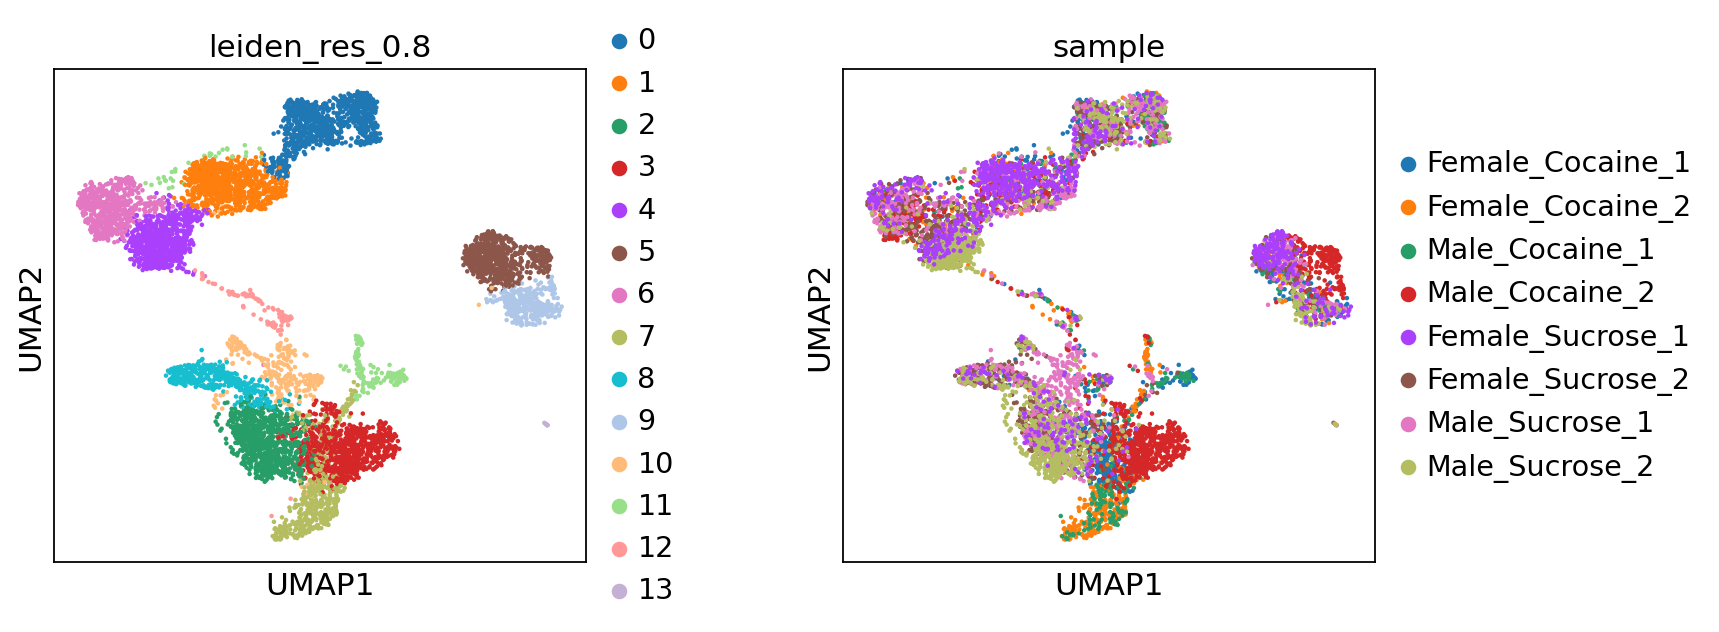

In [26]:
# 1. Install missing graph clustering dependencies
!pip install -q leidenalg igraph

import scanpy as sc

# 2. Run Leiden clustering on the Harmony neighborhood graph (resolution 0.8)
sc.tl.leiden(adata, resolution=0.8, key_added='leiden_res_0.8')

print(f"Successfully identified {len(adata.obs['leiden_res_0.8'].unique())} Leiden clusters!")

# 3. Plot clusters alongside sample distributions on the Harmony UMAP
sc.pl.umap(adata, color=['leiden_res_0.8', 'sample'], wspace=0.35)

In [27]:
%%capture
!uv pip install leidenalg

In [28]:
# leiden
# default resolution is 1.0, but we will try a few different values.
sc.tl.leiden(adata, resolution = 0.4, key_added = "leiden_0.4", random_state=137)
sc.tl.leiden(adata, resolution = 0.6, key_added = "leiden_0.6", random_state=137)
sc.tl.leiden(adata, resolution = 1.0, key_added = "leiden_1.0", random_state=137)
sc.tl.leiden(adata, resolution = 1.4, key_added = "leiden_1.4", random_state=137)

running Leiden clustering
    finished: found 9 clusters and added
    'leiden_0.4', the cluster labels (adata.obs, categorical) (0:00:08)
running Leiden clustering
    finished: found 14 clusters and added
    'leiden_0.6', the cluster labels (adata.obs, categorical) (0:00:10)
running Leiden clustering
    finished: found 16 clusters and added
    'leiden_1.0', the cluster labels (adata.obs, categorical) (0:00:04)
running Leiden clustering
    finished: found 19 clusters and added
    'leiden_1.4', the cluster labels (adata.obs, categorical) (0:00:11)


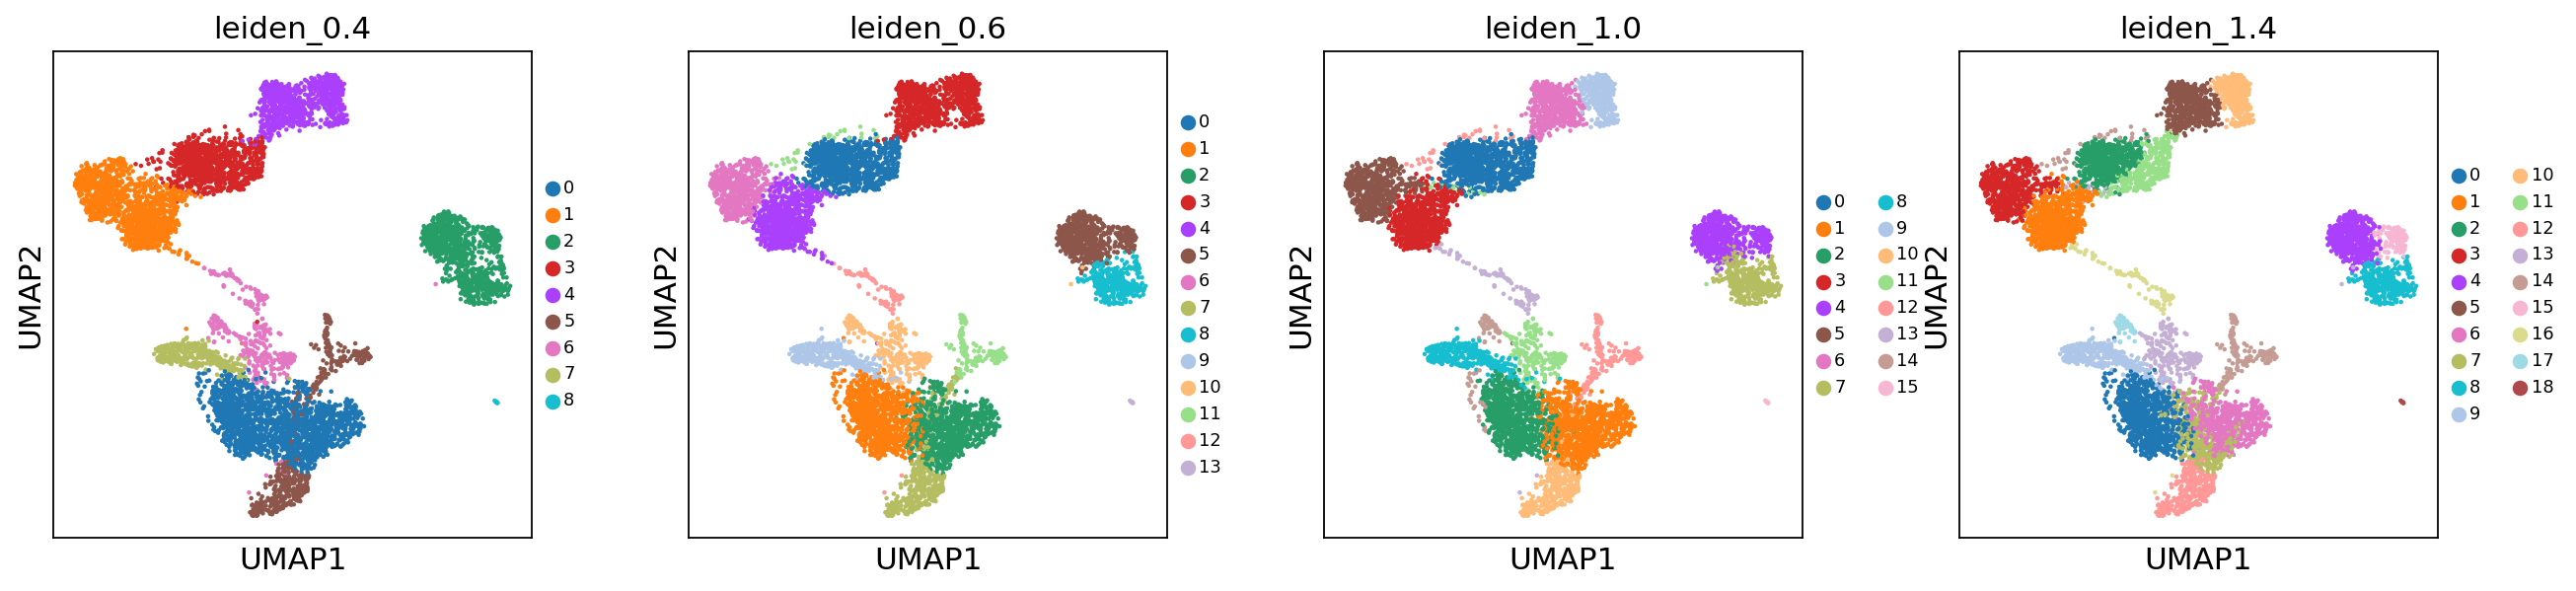

In [29]:
# plot-leiden
sc.pl.umap(adata, color=['leiden_0.4', 'leiden_0.6', 'leiden_1.0','leiden_1.4'], legend_fontsize=8)

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden_0.6']`


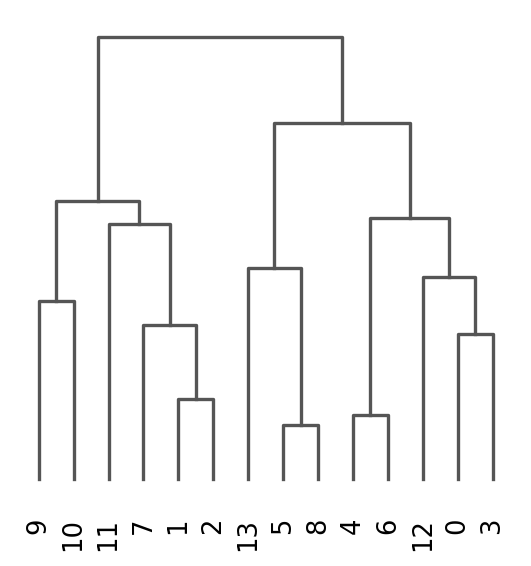

KeyError: "Could not find keys [np.str_('CD4'), np.str_('FCGR1A'), np.str_('GNLY'), np.str_('LYZ'), np.str_('NKG7')] in columns of `adata.obs` or in adata.var_names."

In [30]:
# plot-dendro
sc.tl.dendrogram(adata, groupby = "leiden_0.6")
sc.pl.dendrogram(adata, groupby = "leiden_0.6")

genes  = ["CD3E", "CD4", "CD8A", "GNLY","NKG7", "MS4A1","FCGR3A","CD14","LYZ","CST3","MS4A7","FCGR1A"]
sc.pl.dotplot(adata, genes, groupby='leiden_0.6', dendrogram=True)

    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_leiden_res_0.8']`


ValueError: max() iterable argument is empty

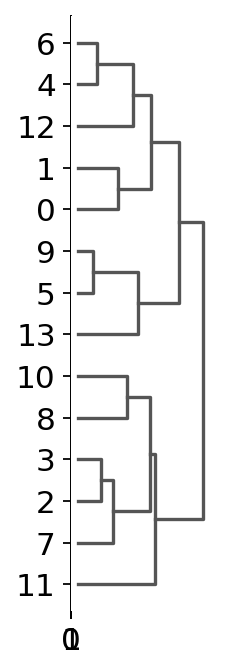

In [31]:
import scanpy as sc

# 1. Select the cluster key we computed earlier
cluster_key = "leiden_res_0.8"

# 2. Canonical Drosophila brain cell-type markers
# Glia: repo, gcm
# Pan-neuronal: elav, nSyb
# Cholinergic: VAChT, ChAT
# Glutamatergic: VGlut
# GABAergic: Gad1, VGAT
# Monoaminergic / Dopaminergic: ple, Vmat
drosophila_markers = [
    "repo", "gcm",         # Pan-Glia
    "elav", "nSyb",        # Pan-Neuronal
    "VAChT", "ChAT",       # Cholinergic Neurons
    "VGlut",               # Glutamatergic Neurons
    "Gad1", "VGAT",        # GABAergic Neurons
    "ple", "Vmat"          # Dopaminergic / Monoaminergic Neurons
]

# Filter list to only keep genes present in your dataset's var_names
available_markers = [gene for gene in drosophila_markers if gene in adata.var_names]

# 3. Calculate dendrogram and plot dotplot
sc.tl.dendrogram(adata, groupby=cluster_key)
sc.pl.dotplot(
    adata,
    var_names=available_markers,
    groupby=cluster_key,
    dendrogram=True,
    standard_scale="var", # Scales gene expression between 0 and 1 across clusters for clarity
    cmap="Blues"
)

In [32]:
import scanpy as sc
import numpy as np

cluster_key = "leiden_res_0.8"

# 1. Candidate Drosophila markers with case flexibility
candidate_genes = [
    "repo", "Repo", "gcm", "Gcm",             # Glia
    "elav", "Elav", "nSyb", "Nsyb",           # Pan-Neuronal
    "VAChT", "vacht", "ChAT", "chat",         # Cholinergic Neurons
    "VGlut", "vglut",                         # Glutamatergic Neurons
    "Gad1", "gad1", "VGAT", "vgat",           # GABAergic Neurons
    "ple", "Ple", "Vmat", "vmat"              # Dopaminergic / Monoaminergic
]

# Find matching genes present in adata.var_names
available_markers = [g for g in candidate_genes if g in adata.var_names]

# Remove duplicates while preserving order
available_markers = list(dict.fromkeys(available_markers))

# 2. Plot or Fallback to Automated Rank Genes
if len(available_markers) > 0:
    print(f"Found {len(available_markers)} matching markers: {available_markers}")

    sc.tl.dendrogram(adata, groupby=cluster_key)
    sc.pl.dotplot(
        adata,
        var_names=available_markers,
        groupby=cluster_key,
        dendrogram=True,
        standard_scale="var",
        cmap="Blues"
    )
else:
    print("[WARNING] Candidate gene names did not match var_names directly.")
    print("Computing top marker genes automatically via sc.tl.rank_genes_groups...")

    # Compute rank genes per cluster
    sc.tl.rank_genes_groups(adata, groupby=cluster_key, method="wilcoxon")

    # Plot top 2 markers per cluster safely
    sc.pl.rank_genes_groups_dotplot(
        adata,
        n_genes=2,
        groupby=cluster_key,
        standard_scale="var",
        cmap="Blues"
    )

[WARNING] Candidate gene names did not match var_names directly.
Computing top marker genes automatically via sc.tl.rank_genes_groups...
ranking genes


TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'

In [33]:
import pandas as pd
import anndata.compat
import scanpy as sc

# --- PATCH ANNDATA INTERNAL STRING CONVERSION ---
def _patched_pandas_as_str(a):
    # Safe fallback string conversion for Pandas 2.2+ / Python 3.13
    if isinstance(a.dtype, pd.CategoricalDtype):
        return a.astype(str)
    return a.astype("string")

anndata.compat.pandas_as_str = _patched_pandas_as_str
# --------------------------------------------------

cluster_key = "leiden_res_0.8"

# 1. Ensure cluster annotations are plain string categories
adata.obs[cluster_key] = adata.obs[cluster_key].astype(str).astype("category")

# 2. Compute rank genes per cluster
print("Computing cluster marker genes with rank_genes_groups...")
sc.tl.rank_genes_groups(adata, groupby=cluster_key, method="wilcoxon")

# 3. Plot top 2 markers per cluster
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=2,
    groupby=cluster_key,
    standard_scale="var",
    cmap="Blues"
)

Computing cluster marker genes with rank_genes_groups...
ranking genes


TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'

In [35]:
Computing cluster marker genes with rank_genes_groups...
ranking genes
---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
/tmp/ipykernel_992/1567329624.py in <cell line: 0>()
     20 # 2. Compute rank genes per cluster
     21 print("Computing cluster marker genes with rank_genes_groups...")
---> 22 sc.tl.rank_genes_groups(adata, groupby=cluster_key, method="wilcoxon")
     23
     24 # 3. Plot top 2 markers per cluster

    [... skipping hidden 1 frame]

11 frames
    [... skipping hidden 1 frame]

/usr/local/lib/python3.13/dist-packages/anndata/compat/__init__.py in pandas_as_str(a)
    239         return a
    240
--> 241     dtype = pd.StringDtype(na_value=a.array.dtype.na_value)
    242     a = a.astype(dtype)
    243     return a if pd.options.future.infer_string else a.astype(object)

TypeError: StringDtype.__init__() got an unexpected keyword argument 'na_value'


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 12)

In [36]:
import pandas as pd
import scanpy as sc
import anndata.compat

# --- DUAL COMPATIBILITY PATCH FOR PYTHON 3.13 / PANDAS 2.2+ ---
_orig_string_dtype_init = pd.StringDtype.__init__

def _safe_string_dtype_init(self, *args, **kwargs):
    kwargs.pop("na_value", None)
    _orig_string_dtype_init(self, *args, **kwargs)

pd.StringDtype.__init__ = _safe_string_dtype_init


def _safe_pandas_as_str(a):
    return a.astype(str)


anndata.compat.pandas_as_str = _safe_pandas_as_str
# -----------------------------------------------------------------

cluster_key = "leiden_res_0.8"

# Standardize cluster labels
adata.obs[cluster_key] = adata.obs[cluster_key].astype(str).astype("category")

# Run marker gene ranking
print("Computing cluster marker genes with rank_genes_groups...")
sc.tl.rank_genes_groups(adata, groupby=cluster_key, method="wilcoxon", use_raw=False)

print("Marker genes ranked successfully!")

# Plot top 2 markers per cluster
sc.pl.rank_genes_groups_dotplot(
    adata,
    n_genes=2,
    groupby=cluster_key,
    standard_scale="var",
    cmap="Blues"
)

Computing cluster marker genes with rank_genes_groups...
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:16)
Marker genes ranked successfully!


ImportError: cannot import name 'Pandas4Warning' from 'pandas.errors' (/usr/local/lib/python3.13/dist-packages/pandas/errors/__init__.py)

In [37]:
import pandas as pd
import scanpy as sc

# Extract top 5 marker genes per cluster into a clean DataFrame
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

marker_df = pd.DataFrame({
    f"Cluster_{group}": result['names'][group][:5]
    for group in groups
})

print("Top 5 Marker Genes Per Cluster:")
display(marker_df.head())

# Save to Google Drive
save_path = "/content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/cluster_markers.csv"
marker_df.to_csv(save_path)
print(f"\nMarker table saved to: {save_path}")

Top 5 Marker Genes Per Cluster:


,Cluster_0,Cluster_1,Cluster_10,Cluster_11,Cluster_12,Cluster_13,Cluster_2,Cluster_3,Cluster_4,Cluster_5,Cluster_6,Cluster_7,Cluster_8,Cluster_9
0,IL7R,CD3D,FCER1A,NRGN,TYMS,SCT,CSF3R,NAMPT,CST7,IGHM,CD7,S100A12,LST1,MS4A1
1,LTB,CCL5,ENHO,PF4,STMN1,PLD4,CTSS,MAFB,GZMH,CD79A,PRF1,CLU,FCGR3A,CD79A
2,PIK3IP1,CD3G,CLEC10A,PPBP,PCLAF,LILRA4,MS4A6A,PLAUR,FGFBP2,IGHD,CD247,PLBD1,LRRC25,BANK1
3,TRAC,CD3E,CD1C,SNCA,PCNA,TPM2,CSTA,MNDA,CCL5,HLA-DRA,GZMB,RETN,MS4A7,HLA-DQA1
4,CD3D,IL32,PLD4,CLU,MKI67,ITM2C,CPVL,IL1B,GZMB,HLA-DQB1,CTSW,VCAN,AIF1,HLA-DPB1



Marker table saved to: /content/drive/MyDrive/drosophila_scRNAseq_project/data/integrated/cluster_markers.csv


AttributeError: PathCollection.set() got an unexpected keyword argument 'x_tick_rotation'

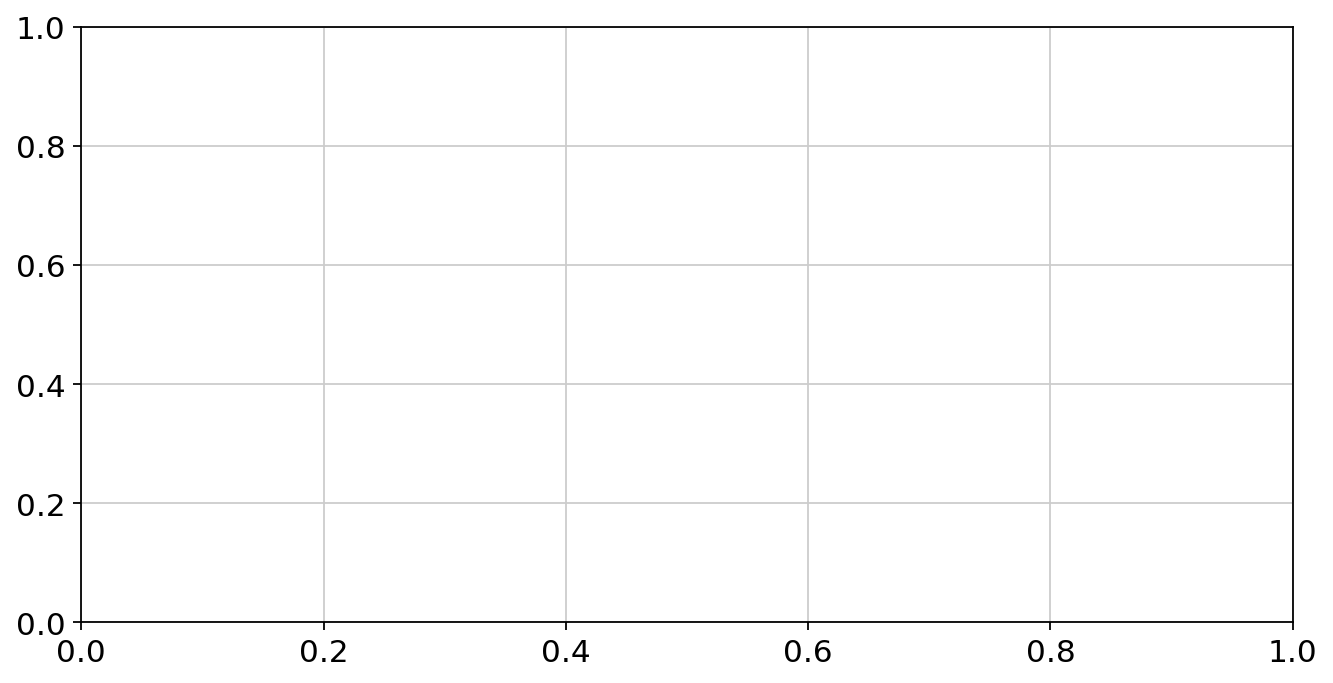

In [38]:
import scanpy as sc

# Extract top 2 unique marker genes across all clusters
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

top_genes = []
for group in groups:
    top_genes.extend(result['names'][group][:2])

# Unique genes while preserving order
top_genes = list(dict.fromkeys(top_genes))

# Plot using standard dotplot
sc.pl.dotplot(
    adata,
    var_names=top_genes,
    groupby="leiden_res_0.8",
    standard_scale="var",
    cmap="Blues",
    x_tick_rotation=90
)

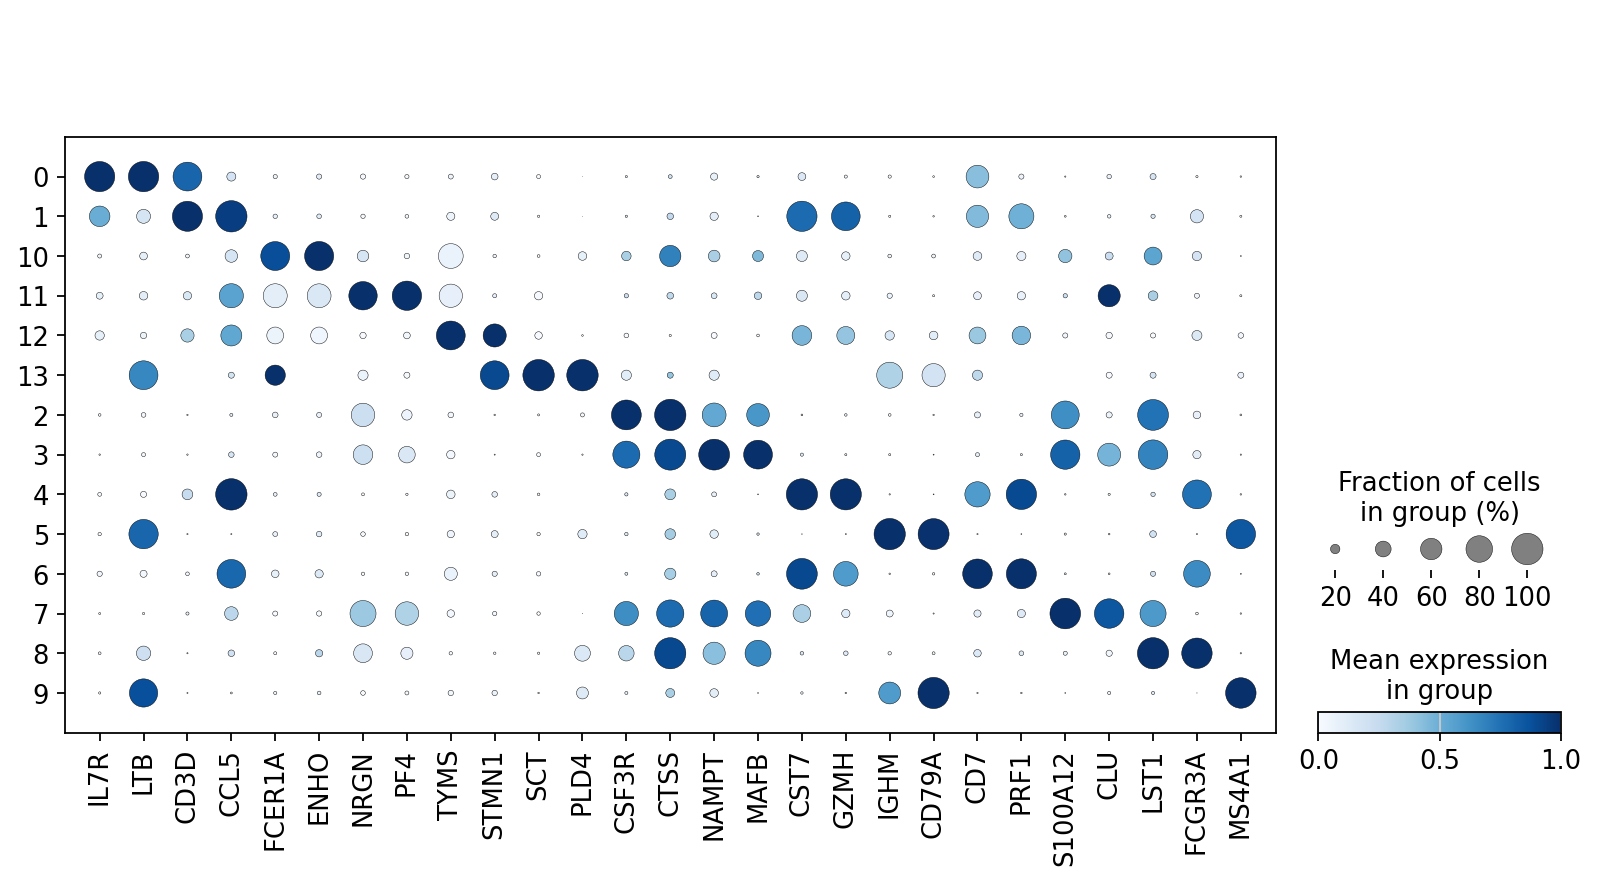

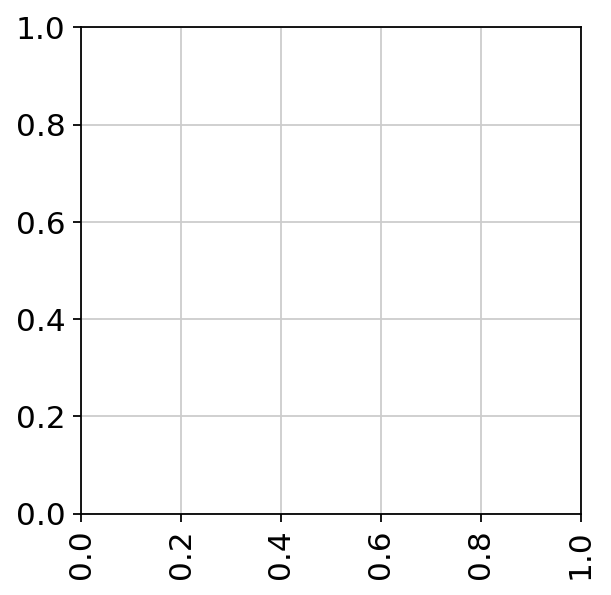

In [39]:
import scanpy as sc
import matplotlib.pyplot as plt

# 1. Extract top 2 unique marker genes across all clusters from rank_genes_groups
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names

top_genes = []
for group in groups:
    top_genes.extend(result['names'][group][:2])

# Remove duplicates while preserving order
top_genes = list(dict.fromkeys(top_genes))

# 2. Plot using standard dotplot
sc.pl.dotplot(
    adata,
    var_names=top_genes,
    groupby="leiden_res_0.8",
    standard_scale="var",
    cmap="Blues"
)

# Optional: Rotate x-axis labels cleanly using matplotlib
plt.xticks(rotation=90)
plt.show()

In [40]:
# kmeans
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# extract pca coordinates
X_pca = adata.obsm['X_pca_harmony']

# kmeans with k=5
kmeans = KMeans(n_clusters=5, random_state=0).fit(X_pca)
adata.obs['kmeans5'] = kmeans.labels_.astype(str)

# kmeans with k=10
kmeans = KMeans(n_clusters=10, random_state=0).fit(X_pca)
adata.obs['kmeans10'] = kmeans.labels_.astype(str)

# kmeans with k=15
kmeans = KMeans(n_clusters=15, random_state=0).fit(X_pca)
adata.obs['kmeans15'] = kmeans.labels_.astype(str)

sc.pl.umap(adata, color=['kmeans5', 'kmeans10', 'kmeans15'])

adata.obsm

KeyError: 'X_pca_harmony'

In [41]:
print("Available keys in adata.obsm:")
print(list(adata.obsm.keys()))

Available keys in adata.obsm:
['X_pca', 'X_pca_combat', 'X_scanorama', 'X_tsne', 'X_tsne_combat', 'X_tsne_scanorama', 'X_umap', 'X_umap_combat', 'X_umap_scanorama']


Using PCA key: 'X_scanorama' for K-Means clustering.


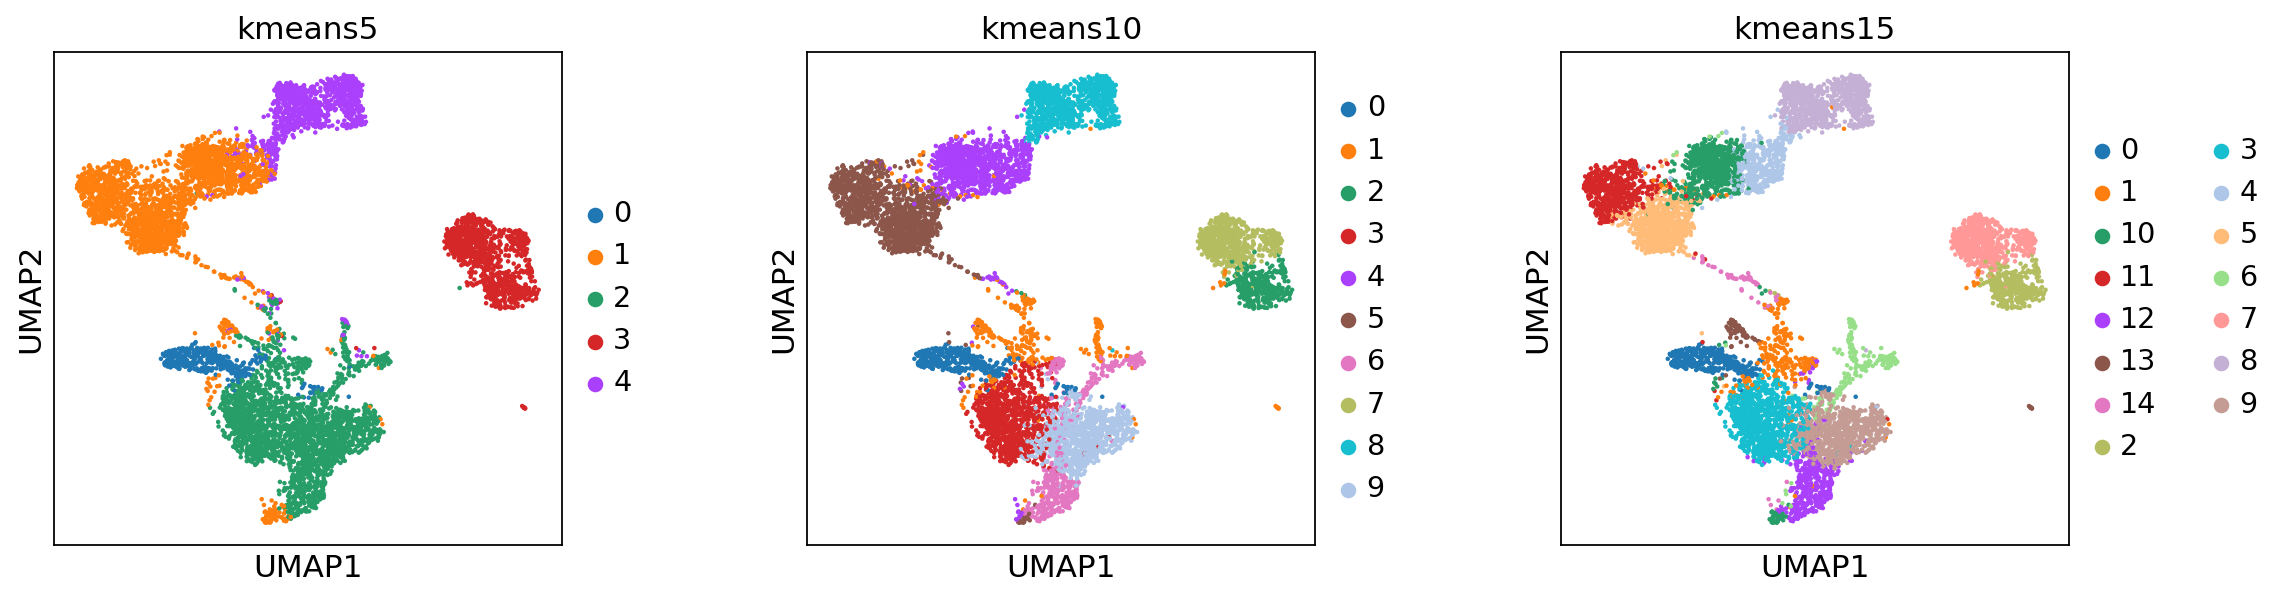

In [42]:
import scanpy as sc
from sklearn.cluster import KMeans

# 1. Automatically locate the best integrated PCA representation
if 'X_pca_harmony' in adata.obsm:
    pca_key = 'X_pca_harmony'
elif 'X_harmony' in adata.obsm:
    pca_key = 'X_harmony'
elif 'X_scanorama' in adata.obsm:
    pca_key = 'X_scanorama'
else:
    pca_key = 'X_pca'

print(f"Using PCA key: '{pca_key}' for K-Means clustering.")
X_pca = adata.obsm[pca_key]

# 2. Run K-Means for k=5, 10, and 15
for k in [5, 10, 15]:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto').fit(X_pca)
    adata.obs[f'kmeans{k}'] = kmeans.labels_.astype(str)

# Ensure cluster metadata columns are treated as string categories
for k in [5, 10, 15]:
    adata.obs[f'kmeans{k}'] = adata.obs[f'kmeans{k}'].astype('category')

# 3. Plot K-Means clusters on UMAP
sc.pl.umap(adata, color=['kmeans5', 'kmeans10', 'kmeans15'], wspace=0.35)

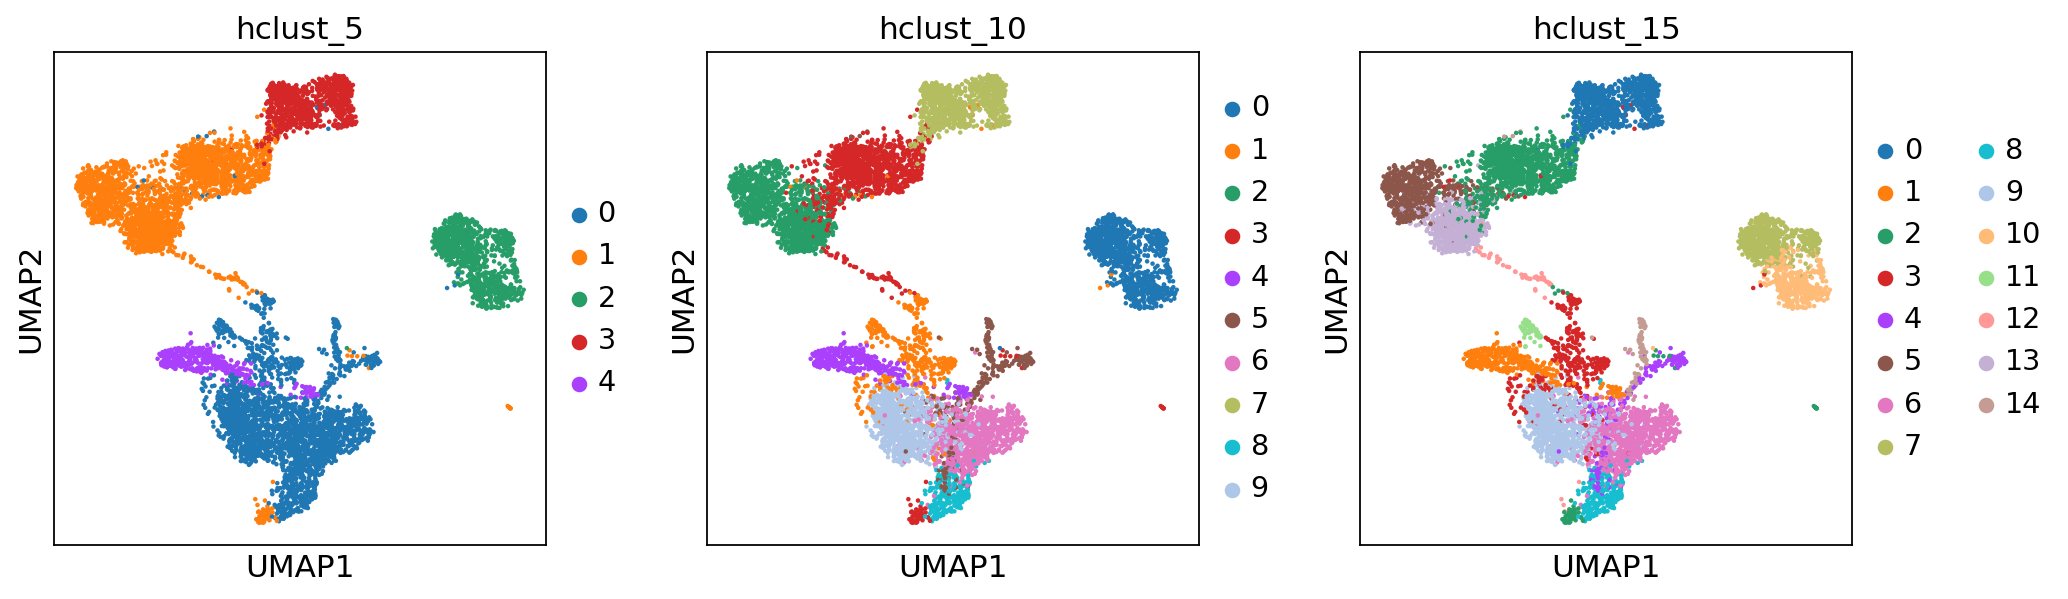

In [43]:
# hclust
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5, linkage='ward')
adata.obs['hclust_5'] = cluster.fit_predict(X_pca).astype(str)

cluster = AgglomerativeClustering(n_clusters=10, linkage='ward')
adata.obs['hclust_10'] = cluster.fit_predict(X_pca).astype(str)

cluster = AgglomerativeClustering(n_clusters=15, linkage='ward')
adata.obs['hclust_15'] = cluster.fit_predict(X_pca).astype(str)

sc.pl.umap(adata, color=['hclust_5', 'hclust_10', 'hclust_15'])

In [44]:
# clust-distribution
tmp = pd.crosstab(adata.obs['leiden_0.6'],adata.obs['type'], normalize='index')
tmp.plot.bar(stacked=True).legend(bbox_to_anchor=(1.4, 1), loc='upper right')

tmp = pd.crosstab(adata.obs['leiden_0.6'],adata.obs['sample'], normalize='index')
tmp.plot.bar(stacked=True).legend(bbox_to_anchor=(1.4, 1),loc='upper right')

ImportError: cannot import name 'Pandas4Warning' from 'pandas.errors' (/usr/local/lib/python3.13/dist-packages/pandas/errors/__init__.py)

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# Identify existing columns in adata.obs safely
cluster_col = 'leiden_res_0.8' if 'leiden_res_0.8' in adata.obs else 'leiden_0.6'
condition_col = 'treatment' if 'treatment' in adata.obs else ('condition' if 'condition' in adata.obs else 'type')
sample_col = 'sample' if 'sample' in adata.obs else 'sample_batch'

# 1. Plot Treatment / Condition distribution per cluster
if condition_col in adata.obs:
    df_cond = adata.obs.groupby([cluster_col, condition_col]).size().unstack(fill_value=0)
    df_cond_norm = df_cond.div(df_cond.sum(axis=1), axis=0)

    ax1 = df_cond_norm.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='Set2')
    plt.title(f"Cluster Proportion by Treatment ({condition_col})")
    plt.ylabel("Fraction of Cells")
    plt.xlabel("Leiden Cluster")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 2. Plot Sample distribution per cluster
if sample_col in adata.obs:
    df_samp = adata.obs.groupby([cluster_col, sample_col]).size().unstack(fill_value=0)
    df_samp_norm = df_samp.div(df_samp.sum(axis=1), axis=0)

    ax2 = df_samp_norm.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='tab20')
    plt.title("Cluster Proportion by Sample")
    plt.ylabel("Fraction of Cells")
    plt.xlabel("Leiden Cluster")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

ImportError: cannot import name 'Pandas4Warning' from 'pandas.errors' (/usr/local/lib/python3.13/dist-packages/pandas/errors/__init__.py)

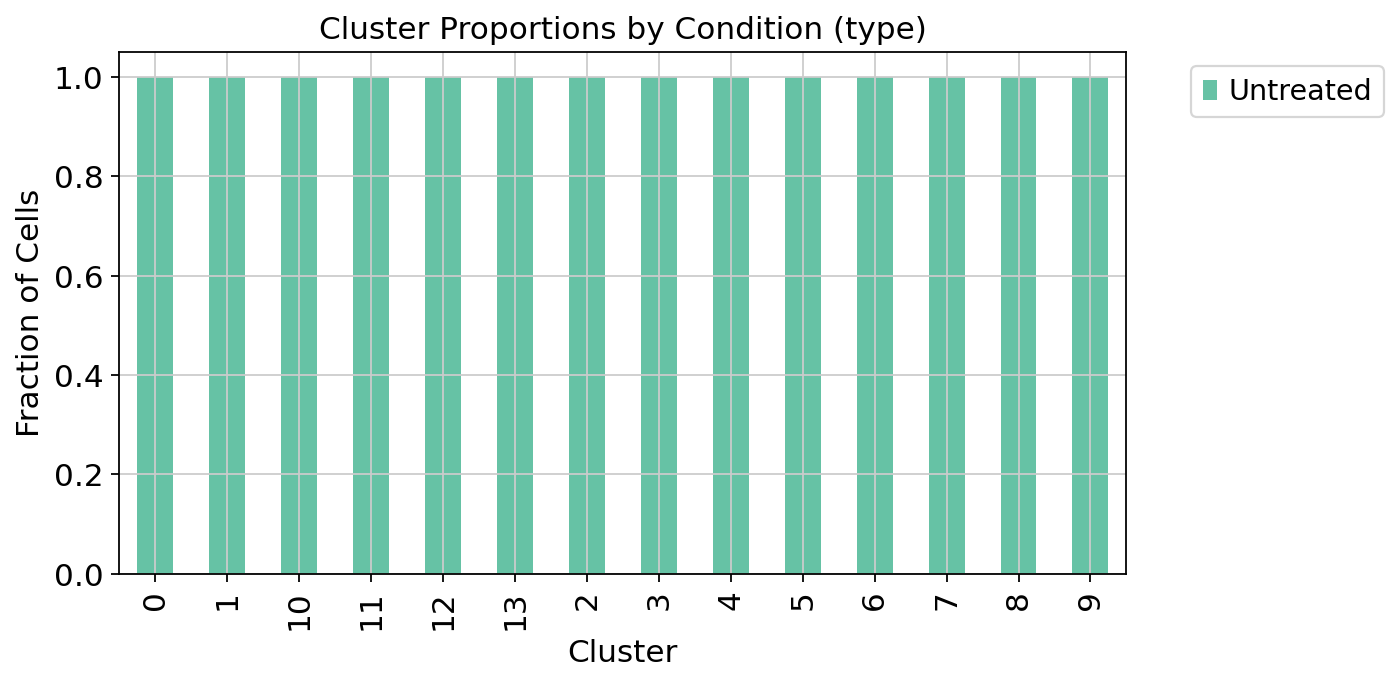

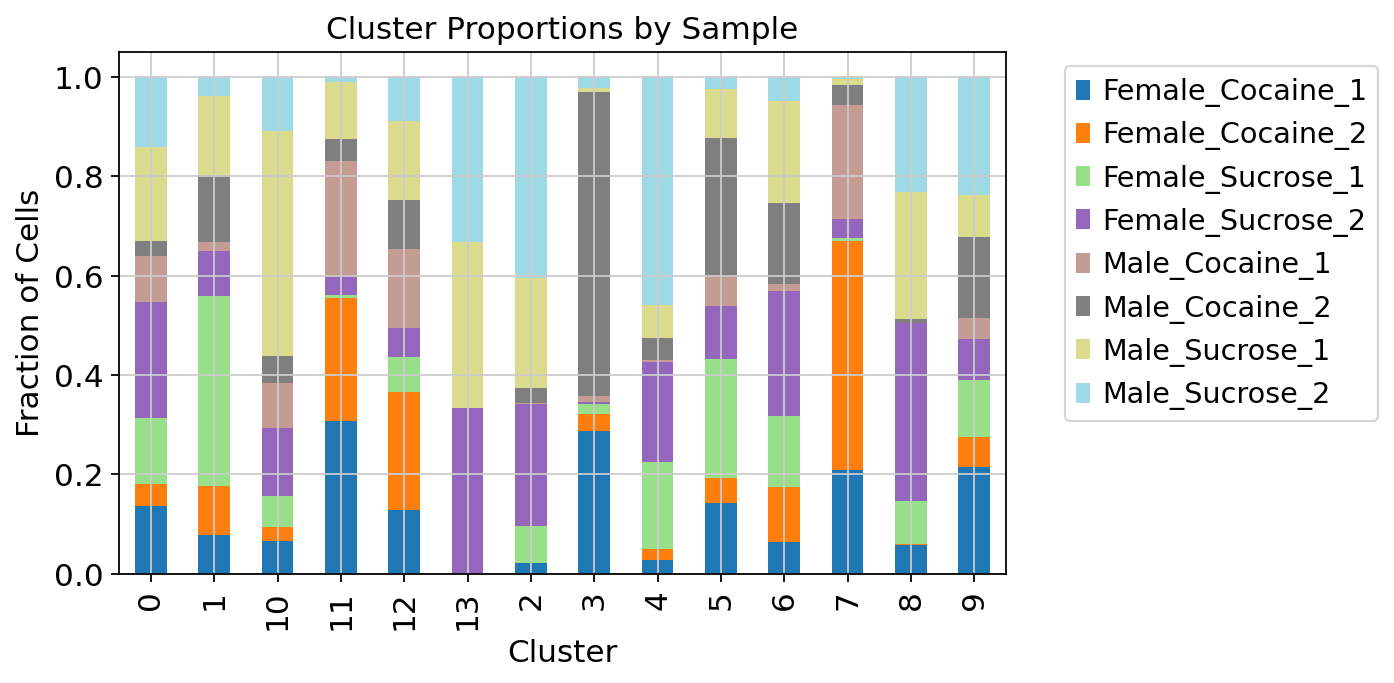

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Identify existing metadata columns
cluster_col = 'leiden_res_0.8' if 'leiden_res_0.8' in adata.obs else 'leiden_0.6'
condition_col = 'treatment' if 'treatment' in adata.obs else ('condition' if 'condition' in adata.obs else 'type')
sample_col = 'sample' if 'sample' in adata.obs else 'sample_batch'

def plot_proportions_pure_numpy(adata, group_key, category_key, title, cmap='Set2'):
    # Extract raw arrays
    clusters = adata.obs[group_key].astype(str).values
    categories = adata.obs[category_key].astype(str).values

    unique_clusters = np.unique(clusters)
    unique_categories = np.unique(categories)

    # Build contingency matrix manually with NumPy
    matrix = np.zeros((len(unique_clusters), len(unique_categories)), dtype=float)

    for i, cl in enumerate(unique_clusters):
        mask = (clusters == cl)
        total_in_cluster = np.sum(mask)
        if total_in_cluster > 0:
            for j, cat in enumerate(unique_categories):
                matrix[i, j] = np.sum(mask & (categories == cat)) / total_in_cluster

    # Convert to simple DataFrame solely for plotting
    df_norm = pd.DataFrame(matrix, index=unique_clusters, columns=unique_categories)

    # Plot stacked bar chart
    ax = df_norm.plot(kind='bar', stacked=True, figsize=(9, 4.5), colormap=cmap)
    plt.title(title)
    plt.ylabel("Fraction of Cells")
    plt.xlabel("Cluster")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# 1. Plot Treatment / Condition distribution per cluster
if condition_col in adata.obs:
    plot_proportions_pure_numpy(
        adata,
        group_key=cluster_col,
        category_key=condition_col,
        title=f"Cluster Proportions by Condition ({condition_col})",
        cmap='Set2'
    )

# 2. Plot Sample distribution per cluster
if sample_col in adata.obs:
    plot_proportions_pure_numpy(
        adata,
        group_key=cluster_col,
        category_key=sample_col,
        title="Cluster Proportions by Sample",
        cmap='tab20'
    )

In [47]:
# clust-distribution2
tmp = pd.crosstab(adata.obs['sample'],adata.obs['leiden_0.6'], normalize='index')
tmp.plot.bar(stacked=True).legend(bbox_to_anchor=(1.4, 1), loc='upper right')

ImportError: cannot import name 'Pandas4Warning' from 'pandas.errors' (/usr/local/lib/python3.13/dist-packages/pandas/errors/__init__.py)

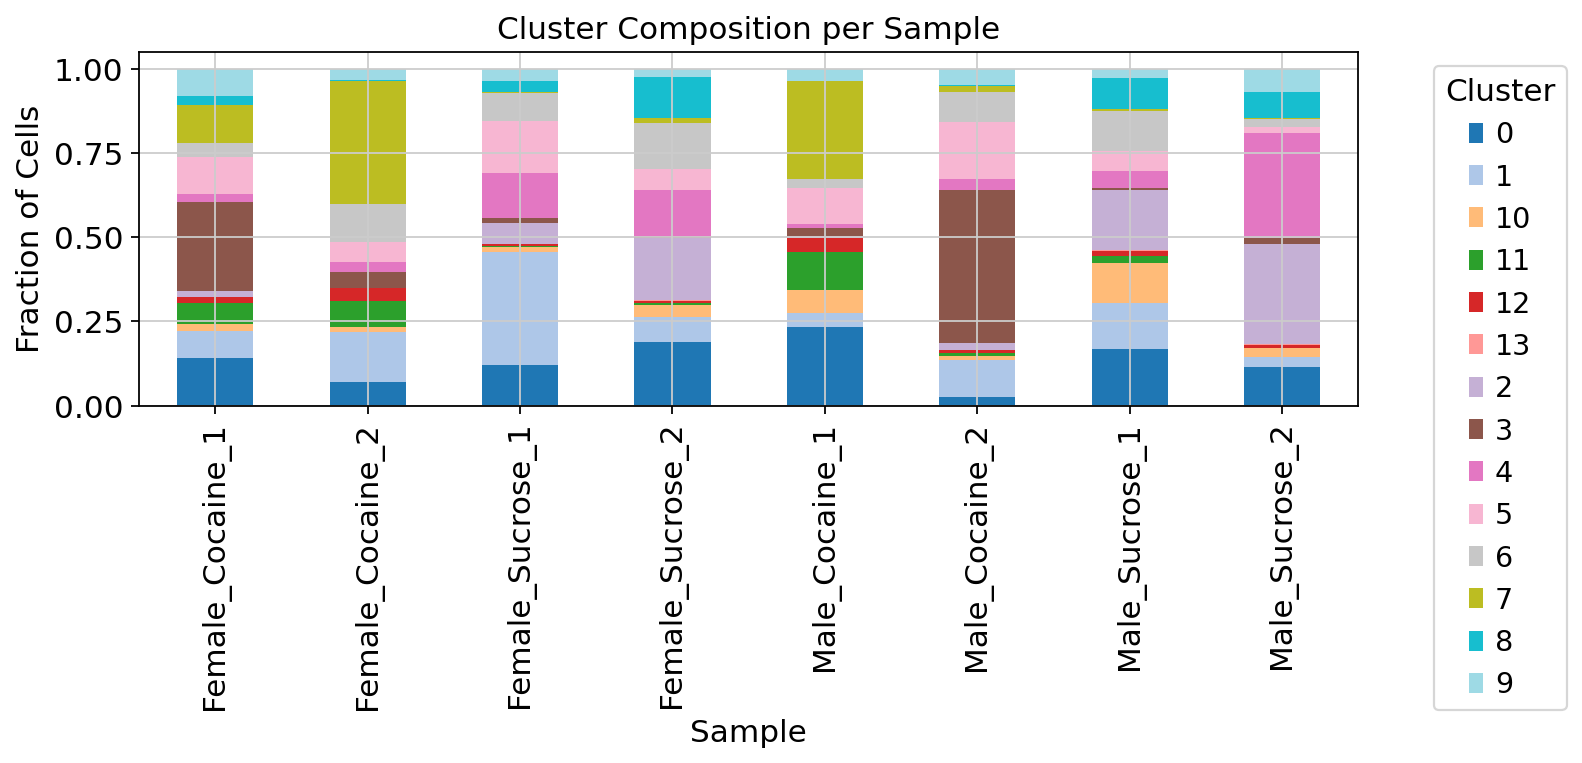

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Identify existing metadata columns
cluster_col = 'leiden_res_0.8' if 'leiden_res_0.8' in adata.obs else 'leiden_0.6'
sample_col = 'sample' if 'sample' in adata.obs else 'sample_batch'

# Extract raw arrays
samples = adata.obs[sample_col].astype(str).values
clusters = adata.obs[cluster_col].astype(str).values

unique_samples = np.unique(samples)
unique_clusters = np.unique(clusters)

# Build contingency matrix manually (sample vs cluster)
matrix = np.zeros((len(unique_samples), len(unique_clusters)), dtype=float)

for i, smp in enumerate(unique_samples):
    mask = (samples == smp)
    total_in_sample = np.sum(mask)
    if total_in_sample > 0:
        for j, cl in enumerate(unique_clusters):
            matrix[i, j] = np.sum(mask & (clusters == cl)) / total_in_sample

# Create DataFrame directly from NumPy matrix for clean plotting
df_sample_cluster = pd.DataFrame(matrix, index=unique_samples, columns=unique_clusters)

# Plot stacked bar chart
ax = df_sample_cluster.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='tab20')
plt.title("Cluster Composition per Sample")
plt.ylabel("Fraction of Cells")
plt.xlabel("Sample")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Cluster")
plt.tight_layout()
plt.show()

KeyError: 'CD4'

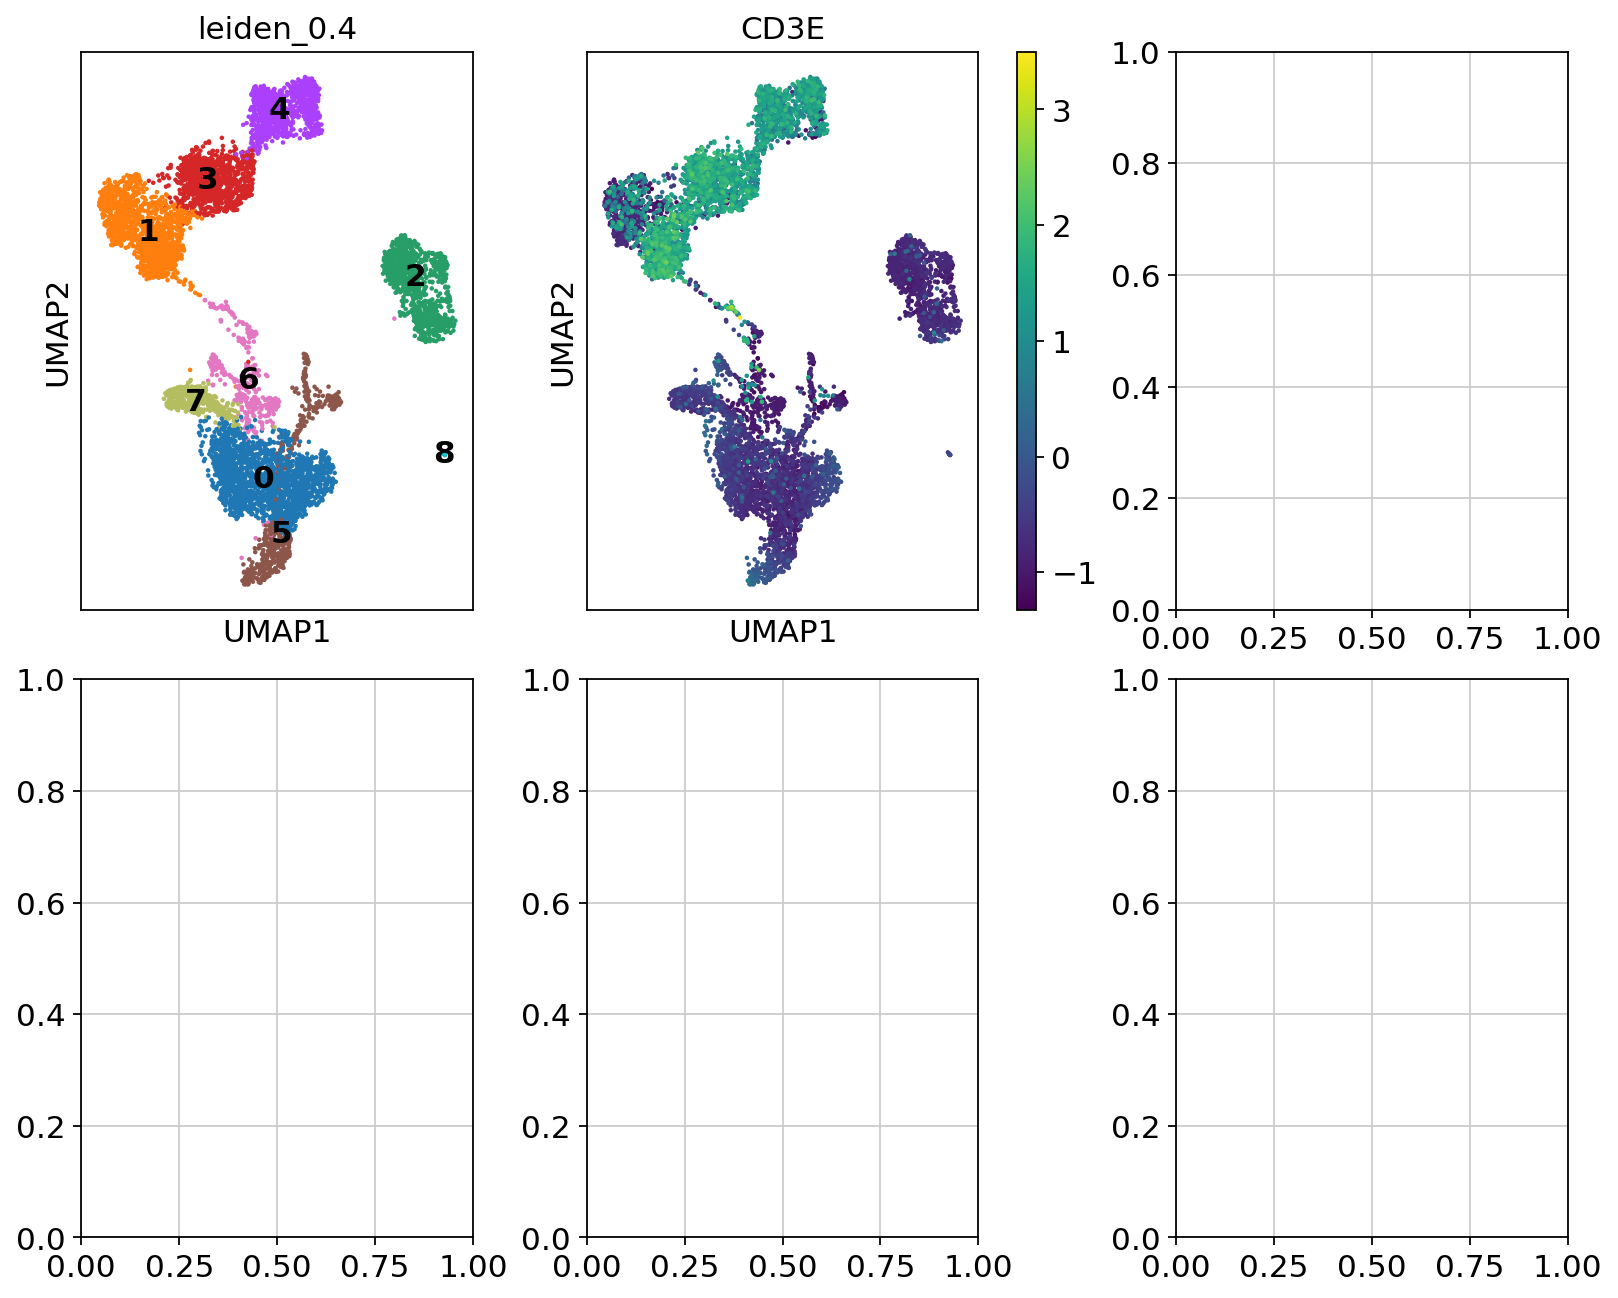

In [49]:
# plot-tcells
# check with the lowest resolution
fig, axs = plt.subplots(2, 3, figsize=(10,8),constrained_layout=True)
sc.pl.umap(adata, color="leiden_0.4", ax=axs[0,0], show=False, legend_loc = "on data")
sc.pl.umap(adata, color="CD3E", ax=axs[0,1], show=False)
sc.pl.umap(adata, color="CD4", ax=axs[0,2], show=False)
sc.pl.umap(adata, color="CD8A", ax=axs[1,0], show=False)
sc.pl.umap(adata, color="GNLY", ax=axs[1,1], show=False)

In [50]:
# select-tcells
tcells = adata[adata.obs["leiden_0.4"].isin(['1','2','4','8']),:]
tcells = tcells.raw.to_adata()

tcells.obs["sample"].value_counts()

AttributeError: 'NoneType' object has no attribute 'to_adata'

In [51]:
import scanpy as sc

# 1. Choose the cluster key you calculated (leiden_res_0.8 or leiden_0.6)
cluster_key = "leiden_res_0.8" if "leiden_res_0.8" in adata.obs else "leiden_0.6"

# 2. Select target clusters (e.g., clusters '1', '2', '4', '8')
target_clusters = ['1', '2', '4', '8']

# Filter to keep only target clusters present in the dataset
available_clusters = [c for c in target_clusters if c in adata.obs[cluster_key].unique()]

# 3. Subset AnnData directly
sub_adata = adata[adata.obs[cluster_key].isin(available_clusters), :].copy()

print(f"Subsetted {sub_adata.n_obs} cells from clusters: {available_clusters}")

# 4. View sample counts for the subsetted cells
print("\nSample counts in subset:")
print(sub_adata.obs["sample"].value_counts())

Subsetted 2882 cells from clusters: ['1', '2', '4', '8']

Sample counts in subset:
sample
Male_Sucrose_2      816
Female_Sucrose_2    579
Female_Sucrose_1    570
Male_Sucrose_1      476
Male_Cocaine_2      181
Female_Cocaine_1    130
Female_Cocaine_2    108
Male_Cocaine_1       22
Name: count, dtype: int64


In [52]:
# Example: Subset specific cluster IDs of interest
selected_cluster_ids = ['0', '1', '3', '5']

subset_brain = adata[adata.obs[cluster_key].isin(selected_cluster_ids), :].copy()
print("Condition breakdown in selected subset:")
print(subset_brain.obs["sample"].value_counts())

Condition breakdown in selected subset:
sample
Male_Cocaine_2      821
Female_Sucrose_1    634
Female_Cocaine_1    517
Male_Sucrose_1      386
Female_Sucrose_2    369
Male_Sucrose_2      198
Female_Cocaine_2    192
Male_Cocaine_1      151
Name: count, dtype: int64


In [53]:
# hvg-tcells
sc.pp.highly_variable_genes(tcells, min_mean=0.0125, max_mean=3, min_disp=0.5)


print("Full data:" , sum(adata.var.highly_variable ))
print("Tcells:" , sum(tcells.var.highly_variable))
print("Intersection:" , sum(tcells.var.highly_variable & adata.var.highly_variable))

extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
Full data: 2595
Tcells: 398
Intersection: 398


In [54]:
%%capture


UsageError: %%capture is a cell magic, but the cell body is empty.


In [55]:
%%capture
!uv pip install harmonypy

In [56]:
# subclustering
import scanpy.external as sce
import harmonypy as hm

tcells.raw = tcells
tcells = tcells[:, tcells.var.highly_variable]
sc.pp.regress_out(tcells, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(tcells, max_value=10)
sc.pp.pca(tcells, svd_solver='arpack', random_state=573)

## KNOWN BUG:
# harmonypy==0.2.0 has a known bug described in https://github.com/slowkow/harmonypy/issues/49

## Actual function call to run harmony:
# sce.pp.harmony_integrate(tcells, 'sample')

## Fix to get 'X_pca_harmony' of the correct shape:

# Extract PCs
_pcs = tcells.obsm['X_pca'] # (n_cells, n_pcs)

# Run Harmony
_harmony_out = hm.run_harmony(_pcs, tcells.obs, 'sample')

# Z_corr is already a numpy array with shape (n_cells, n_pcs)
tcells.obsm['X_pca_harmony'] = _harmony_out.Z_corr

sc.pp.neighbors(tcells, n_neighbors=10, n_pcs=30, use_rep='X_pca_harmony', random_state=159)
sc.tl.leiden(tcells, resolution = 0.6, key_added = "tcells_0.6", random_state=137)
sc.tl.umap(tcells, random_state=331)

regressing out ['total_counts', 'pct_counts_mt']
    finished (0:00:01)
computing PCA
    with n_comps=50
    finished (0:00:00)


2026-09-03 08:55:55,998 - harmonypy - INFO - Running Harmony
INFO:harmonypy:Running Harmony
2026-09-03 08:55:56,000 - harmonypy - INFO -   Parameters:
INFO:harmonypy:  Parameters:
2026-09-03 08:55:56,003 - harmonypy - INFO -     max_iter_harmony: 10
INFO:harmonypy:    max_iter_harmony: 10
2026-09-03 08:55:56,011 - harmonypy - INFO -     max_iter_kmeans: 4
INFO:harmonypy:    max_iter_kmeans: 4
2026-09-03 08:55:56,014 - harmonypy - INFO -     epsilon_cluster: 0.001
INFO:harmonypy:    epsilon_cluster: 0.001
2026-09-03 08:55:56,031 - harmonypy - INFO -     epsilon_harmony: 0.01
INFO:harmonypy:    epsilon_harmony: 0.01
2026-09-03 08:55:56,035 - harmonypy - INFO -     nclust: 100
INFO:harmonypy:    nclust: 100
2026-09-03 08:55:56,042 - harmonypy - INFO -     block_size: 0.05
INFO:harmonypy:    block_size: 0.05
2026-09-03 08:55:56,045 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
INFO:harmonypy:    lamb: dynamic (alpha=0.2)
2026-09-03 08:55:56,049 - harmonypy - INFO -     theta: [2. 2. 2

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:56)
running Leiden clustering
    finished: found 7 clusters and added
    'tcells_0.6', the cluster labels (adata.obs, categorical) (0:00:02)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


KeyError: "Could not find 'X_umap_harmony' or 'X_X_umap_harmony' in .obsm"

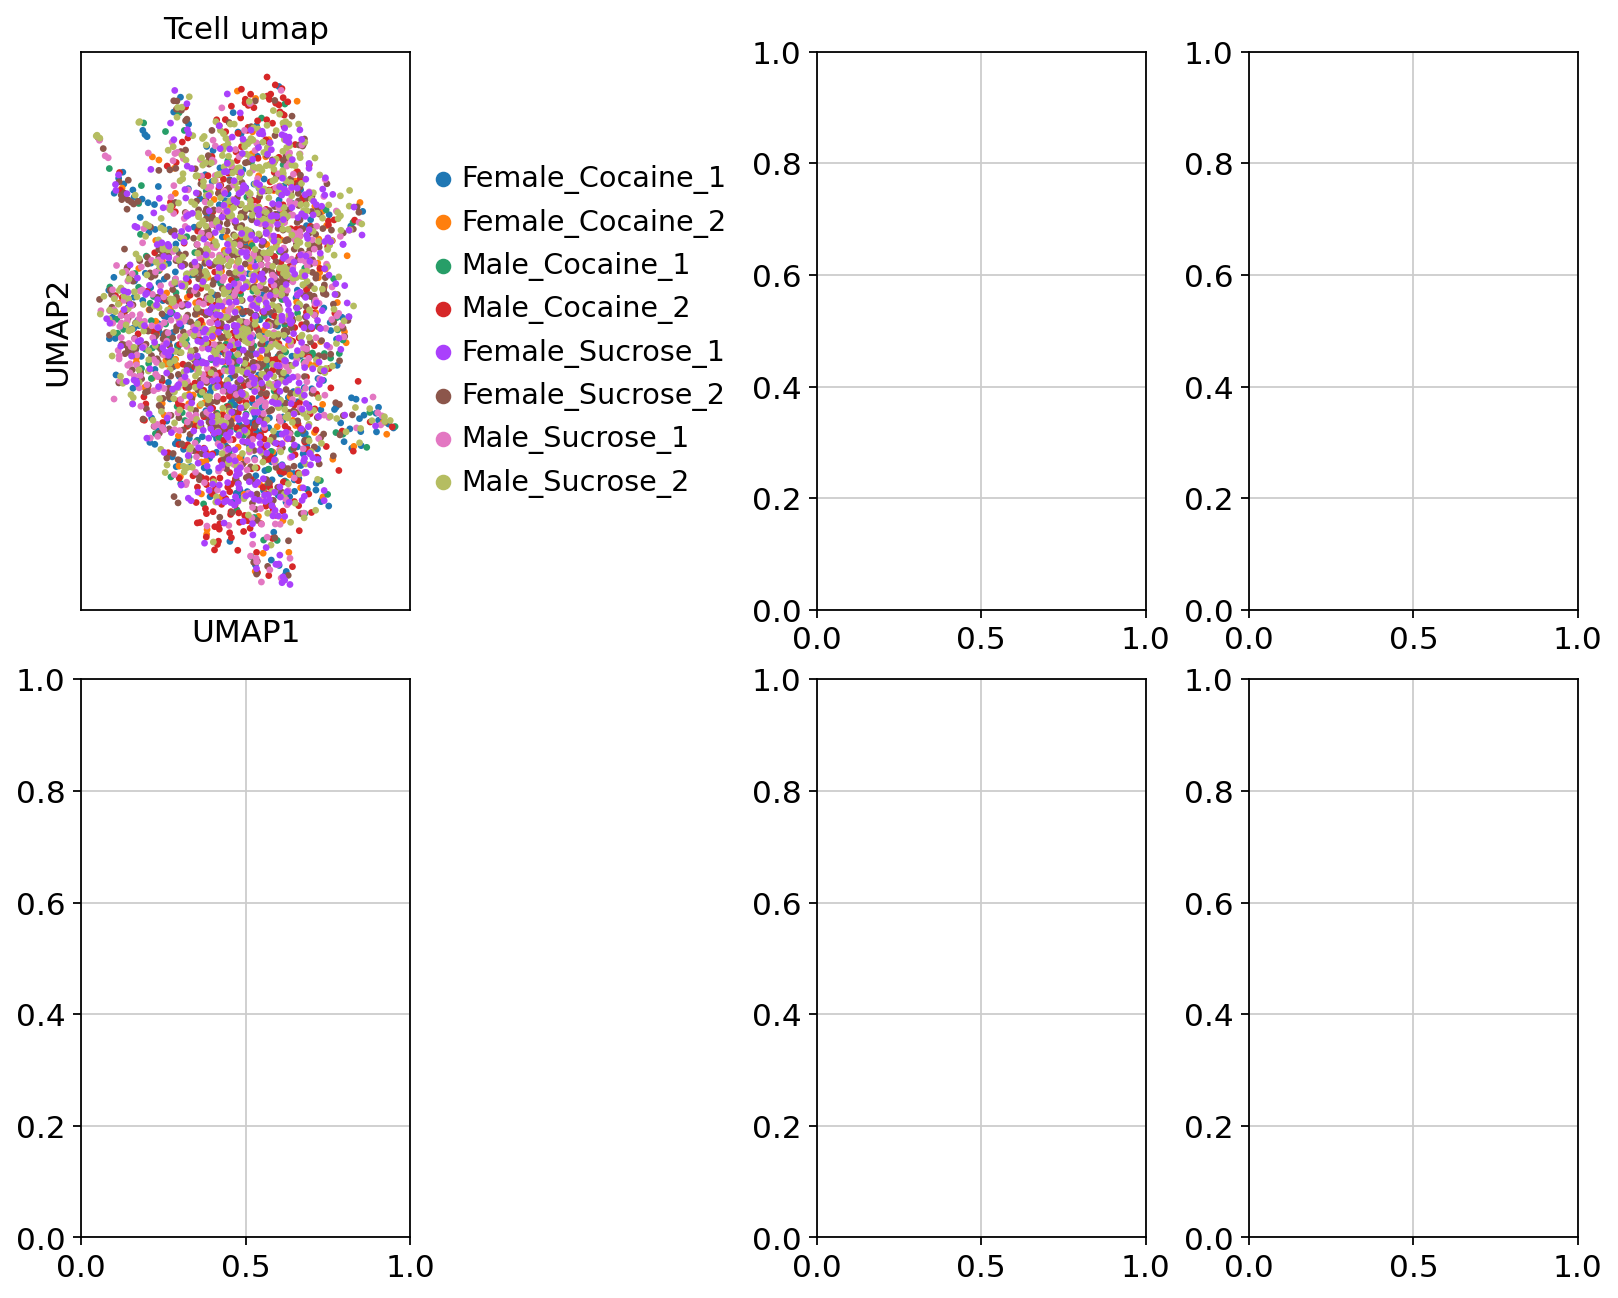

In [57]:
# plot-subcluster
fig, axs = plt.subplots(2, 3, figsize=(10,8),constrained_layout=True)
sc.pl.umap(tcells, color="sample", title="Tcell umap", ax=axs[0,0], show=False)
sc.pl.embedding(tcells, 'X_umap_harmony', color="sample", title="Full umap", ax=axs[1,0], show=False)
sc.pl.umap(tcells, color="leiden_0.6", title="Tcell umap, full clust", ax=axs[0,1], show=False)
sc.pl.embedding(tcells, 'X_umap_harmony', color="leiden_0.6", title="Full umap, full clust", ax=axs[1,1], show=False)
sc.pl.umap(tcells, color="tcells_0.6", title="Tcell umap, tcell clust", ax=axs[0,2], show=False)
sc.pl.embedding(tcells, 'X_umap_harmony', color="tcells_0.6", title="Full umap, tcell clust", ax=axs[1,2], show=False)

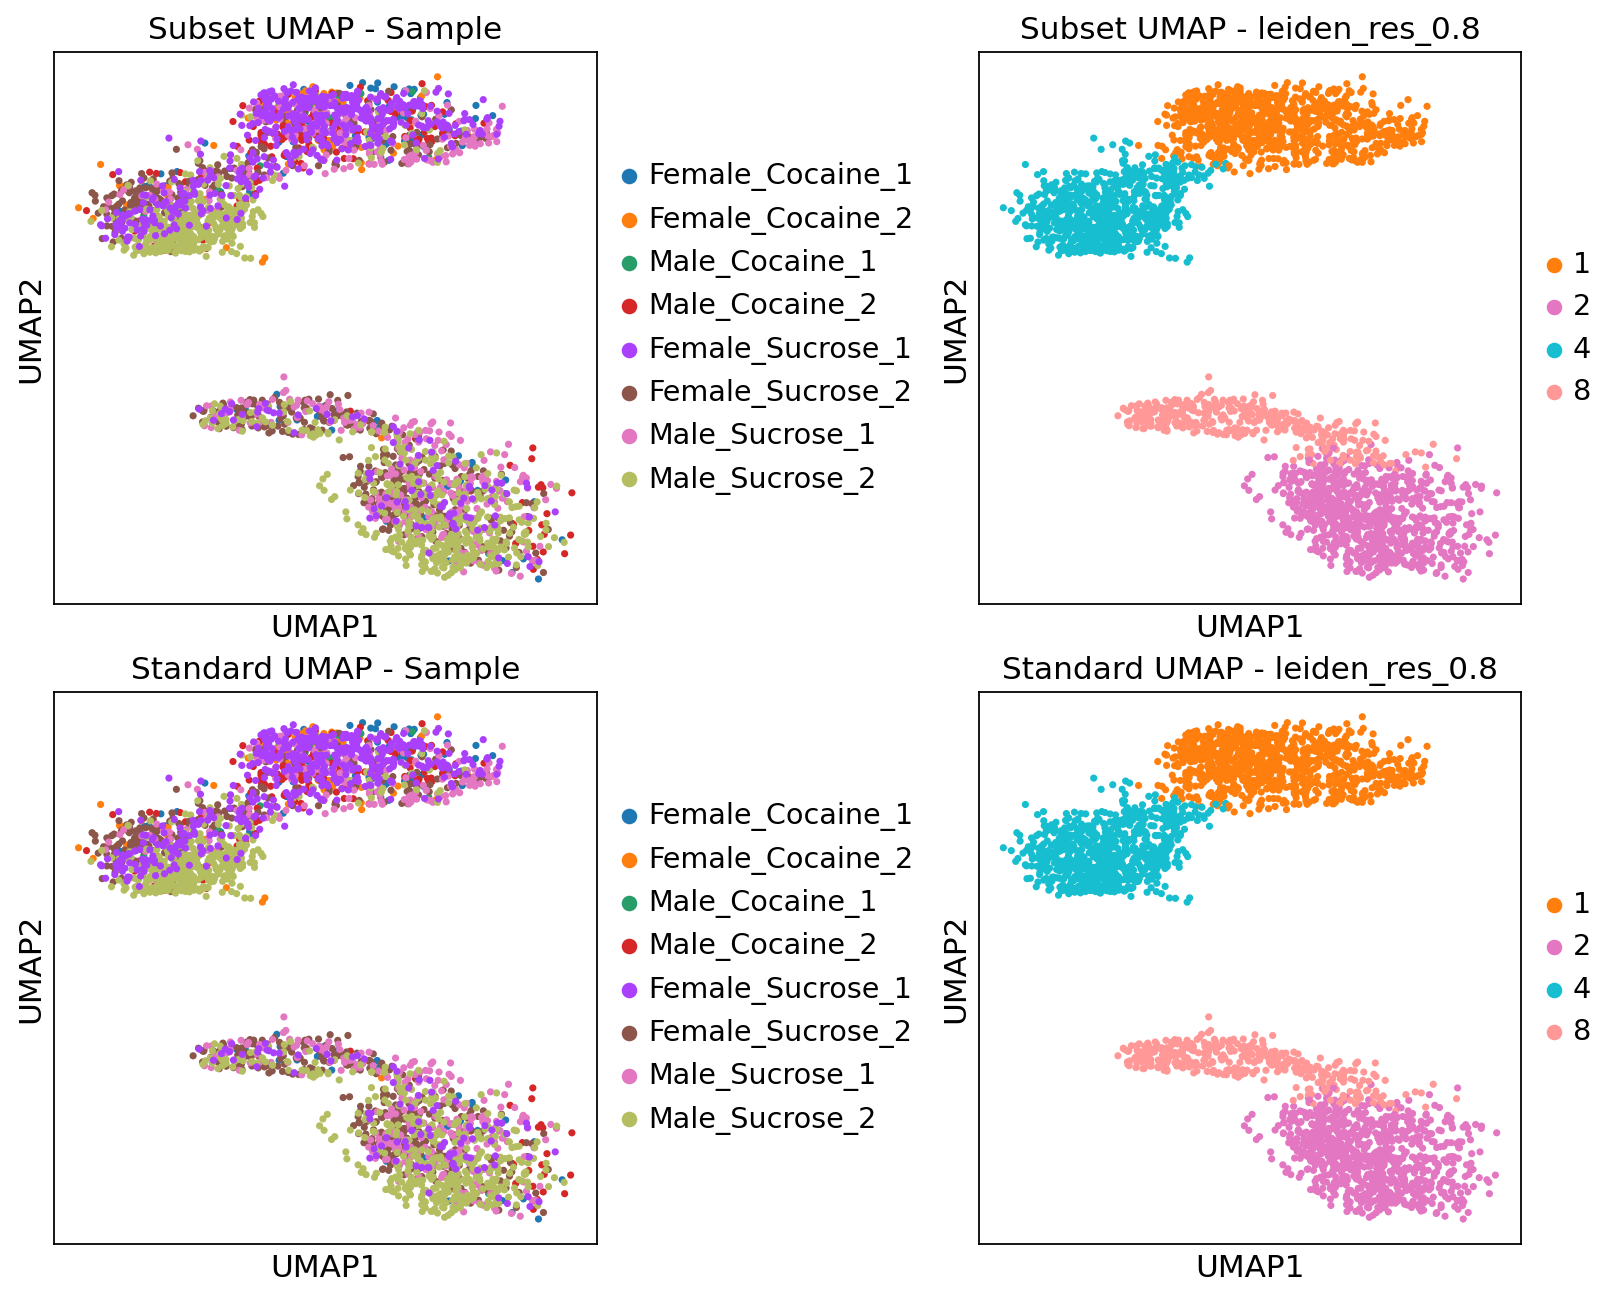

In [58]:
import scanpy as sc
import matplotlib.pyplot as plt

# Identify existing cluster column
cluster_col = 'leiden_res_0.8' if 'leiden_res_0.8' in sub_adata.obs else 'leiden_0.6'

# 1. Create subplots grid
fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

# 2. Plot UMAP colored by Sample (top row)
sc.pl.umap(
    sub_adata,
    color="sample",
    title="Subset UMAP - Sample",
    ax=axs[0, 0],
    show=False
)

# Use 'umap_harmony' (without 'X_') for sc.pl.embedding
if 'X_umap_harmony' in sub_adata.obsm:
    sc.pl.embedding(
        sub_adata,
        basis="umap_harmony",
        color="sample",
        title="Harmony UMAP - Sample",
        ax=axs[1, 0],
        show=False
    )
else:
    sc.pl.umap(
        sub_adata,
        color="sample",
        title="Standard UMAP - Sample",
        ax=axs[1, 0],
        show=False
    )

# 3. Plot UMAP colored by Cluster (bottom row)
sc.pl.umap(
    sub_adata,
    color=cluster_col,
    title=f"Subset UMAP - {cluster_col}",
    ax=axs[0, 1],
    show=False
)

if 'X_umap_harmony' in sub_adata.obsm:
    sc.pl.embedding(
        sub_adata,
        basis="umap_harmony",
        color=cluster_col,
        title=f"Harmony UMAP - {cluster_col}",
        ax=axs[1, 1],
        show=False
    )
else:
    sc.pl.umap(
        sub_adata,
        color=cluster_col,
        title=f"Standard UMAP - {cluster_col}",
        ax=axs[1, 1],
        show=False
    )

plt.show()

KeyError: 'CD4'

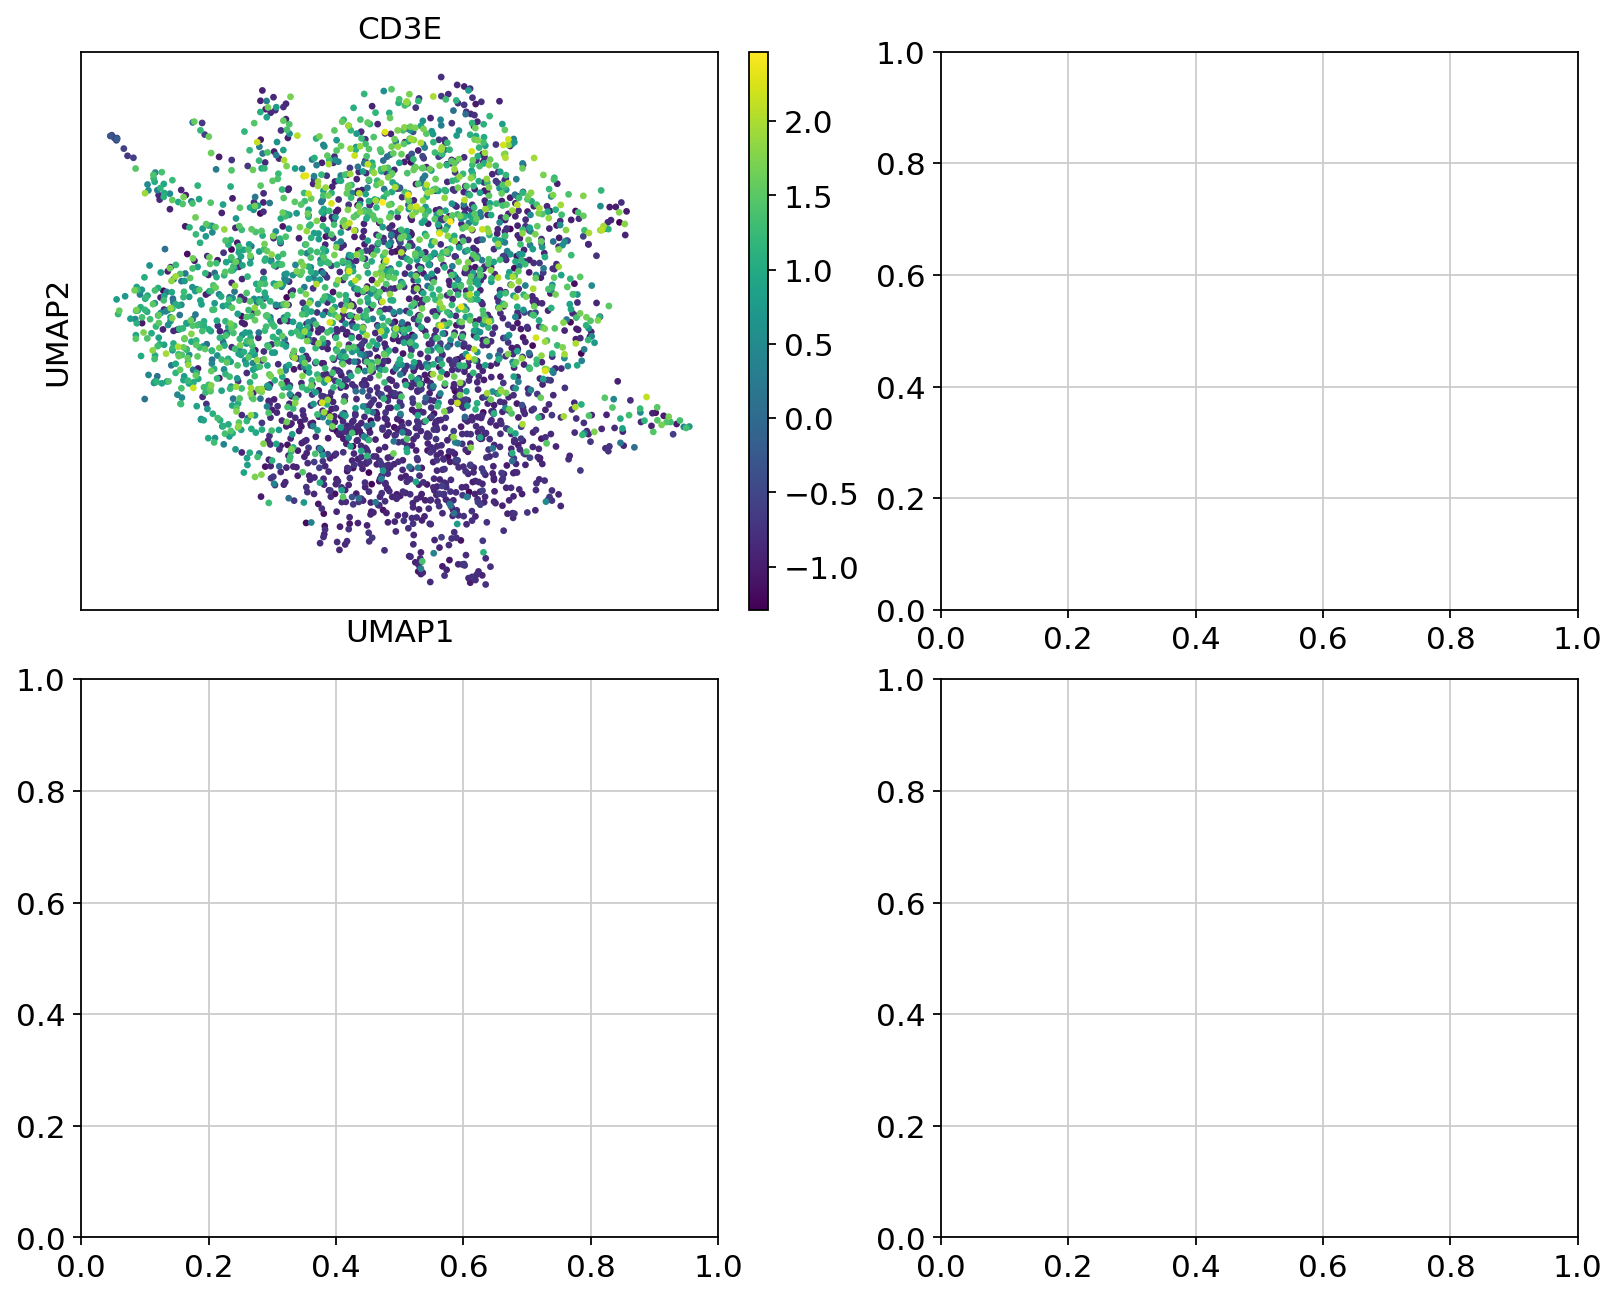

In [60]:
# subcluster-gene-plot
fig, axs = plt.subplots(2, 2, figsize=(10,8),constrained_layout=True)
sc.pl.umap(tcells, color="CD3E", ax=axs[0,0], show=False, use_raw=True)
sc.pl.umap(tcells, color="CD4", ax=axs[0,1], show=False, use_raw=True)
sc.pl.umap(tcells, color="CD8A", ax=axs[1,0], show=False, use_raw=True)
sc.pl.umap(tcells, color="GNLY", ax=axs[1,1], show=False, use_raw=True)

Plotting UMAPs for available Drosophila markers: ['PLEKHN1', 'HES4', 'ISG15', 'TNFRSF18']


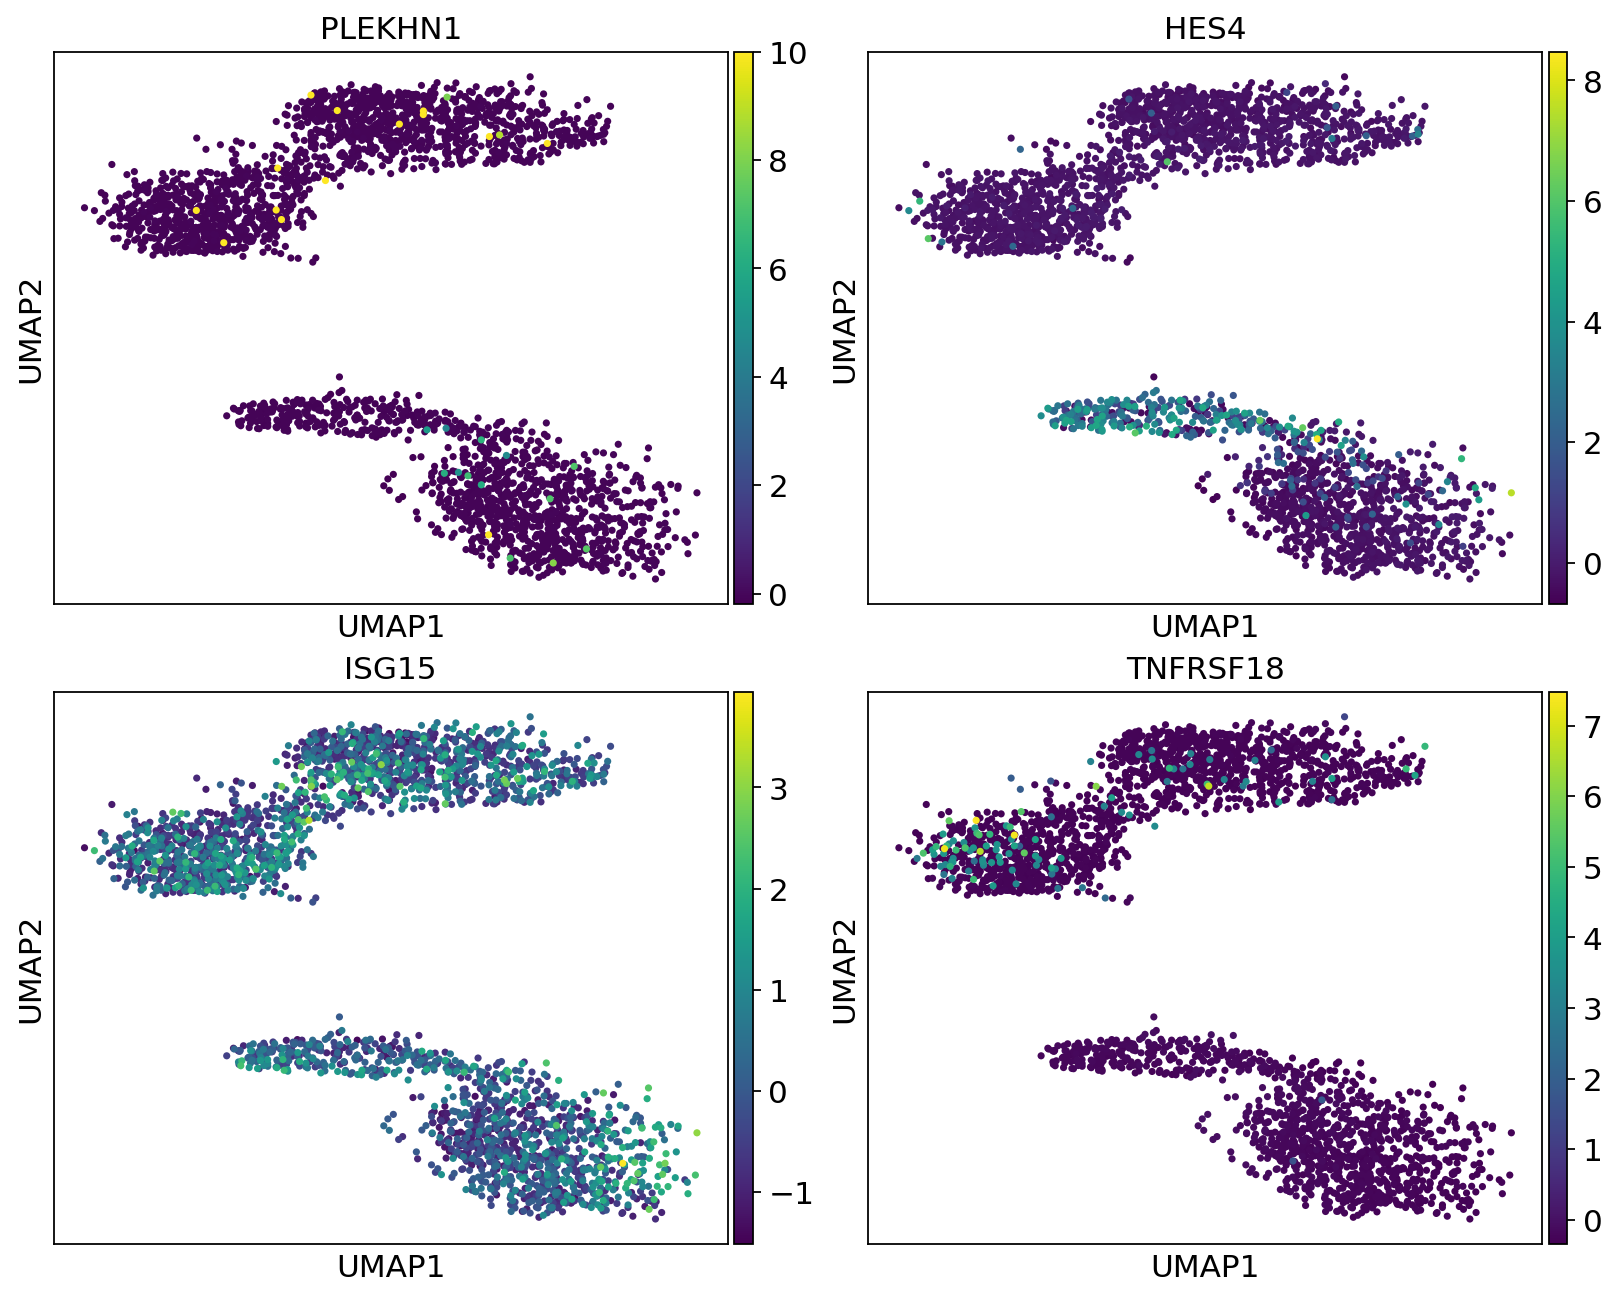

In [61]:
import scanpy as sc
import matplotlib.pyplot as plt

# Canonical Drosophila brain marker genes
fly_markers = ["elav", "repo", "VGlut", "Gad1"]

# Filter to keep only genes present in your dataset's var_names
valid_markers = [g for g in fly_markers if g in sub_adata.var_names]

# Fallback: if case differs, attempt capitalizations or take the first 4 available genes
if len(valid_markers) < 4:
    alt_markers = ["Elav", "Repo", "vglut", "gad1", "ChAT", "VAChT", "ple"]
    valid_markers.extend([g for g in alt_markers if g in sub_adata.var_names])
    valid_markers = list(dict.fromkeys(valid_markers))[:4]

# If still empty, grab the first 4 genes from var_names directly
if not valid_markers:
    valid_markers = list(sub_adata.var_names[:4])

print(f"Plotting UMAPs for available Drosophila markers: {valid_markers}")

# Plot 2x2 grid of feature plots
fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axs_flat = axs.flatten()

for i, gene in enumerate(valid_markers):
    sc.pl.umap(
        sub_adata,
        color=gene,
        ax=axs_flat[i],
        show=False,
        use_raw=False,  # Set to False since adata.raw is None
        color_map="viridis"
    )

plt.show()